In [1]:
import tensorflow as tf
#import levenberg_marquardt as lm
import scipy.stats
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import seaborn as sns
from glob import glob
import xarray as xr
#import typhon as ty
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/')
print(sys.path)
#import src

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

2025-07-30 18:01:34.144060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753891294.229104 2392123 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753891294.253724 2392123 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-30 18:01:34.458367: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


['/home/u/u301032/lib/python', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python312.zip', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/lib-dynload', '', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/setuptools/_vendor', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/']


## Load preprocessed training data

### **Please define altitude**


In [2]:
flight_levels =[11400,12650,13000,13250,13600,13850,14450,15000	]
altitude = 13850 #from prep-for-NN-training.py script
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 

In [3]:
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 

data=[]
names=[ 'IWV', 'IWP', 'LWP','t_steps','cell_selection']
for i in range(len(names)):
    data.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_' + names[i] + '.npy'))
IWV, IWP, LWP,t_steps,cell_selection =data
IWP=1000*IWP
LWP=1000*LWP
TBs_array=[]
mu_array=[]
sigma_array=[]

#for altitude in flight_levels:
#    TBs_array.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy'))
TBs=np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy')


#### Filter for unrealistic BTs missing and determine calculation of flight level


In [4]:
TB_input_vector=TBs
"""
# exclude profiles with unrealistic pamtra simulations
TBs[TBs[:,20]<230] = np.nan   # TODO what are in our case unrealistic values?
TB_input_vector = TBs[~np.isnan(TBs).any(axis=1),:] #TODO: count NANs. If NAN do not just drop , as index would get messed up
IWP = IWP[~np.isnan(TBs).any(axis=1)]
LWP = LWP[~np.isnan(TBs).any(axis=1)]
IWV = IWV[~np.isnan(TBs).any(axis=1)]
"""
if np.count_nonzero(np.isnan(TBs)) > 0:
    print("NaN values in Brightnesstemperature array. This may influence the rest of the Retrievaldeveloment, as they are not being filtered.")


In [7]:
# set IWP values below 1gm2 to zero #TODO check what this means in tropics eg literature, histograms Because Icon has nearly no true zeroes
IWP[IWP<1]=0.
LWP[LWP<1]=0.



In [8]:
TBs.shape
# Only necessary if one wants to exclude certain frequencies.
TB_input_vector = np.concatenate((
        TB_input_vector[:,0:7], # K-Band
        TB_input_vector[:,7:14], # V-Band
        TB_input_vector[:,14:15], # W-Band
        TB_input_vector[:,15:19], # F-Band
        TB_input_vector[:,19:]), # G-Band
        axis=1)
TB_input_vector.shape

if (len(t_steps)*len(cell_selection)!=(TB_input_vector.shape[0])):
    print("Shape of TB does not match cell and time steps. Please check.")

len(t_steps)

33

### Splitting Tesst and Trainings Data
#### Here timestepwise

In [9]:
def splitting_in_train_test_validate(A,t_steps,slices_train,slices_validate,slices_test):    
    # Splits in timesteps
    x=np.arange(0,A.shape[0]+1,A.shape[0]/len(t_steps))
    x=x.astype(int)
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_train])
    train=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_validate])
    validate=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_test])
    test=  A[indexes]
    
    return train,test,validate



In [8]:
# For old runs
slices_train=[[0,2],[4,6],[8,10],[12,14]]
slices_validate=[[2,3],[7,8],[10,11]]
slices_test=[[3,4],[6,7],[11,12]]




train_TB, test_TB, validate_TB = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
train_IWV, test_IWV, validate_IWV = splitting_in_train_test_validate(IWV,t_steps,slices_train,slices_validate,slices_test)
train_LWP, test_LWP, validate_LWP = splitting_in_train_test_validate(LWP,t_steps,slices_train,slices_validate,slices_test)
train_IWP, test_IWP, validate_IWP = splitting_in_train_test_validate(IWP,t_steps,slices_train,slices_validate,slices_test)

In [10]:
# For new runs

a=np.arange(1,33,4)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_validate=np.asarray(l)    
a=np.arange(3,33,4)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_test=np.asarray(l)   
a=np.arange(0,33,2)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_train=np.asarray(l)    
for i in range(len(slices_validate)):
    print(slices_train[2*i])
    print(slices_validate[i])
    print(slices_train[2*i+1])
    print(slices_test[i])





train_TB, test_TB, validate_TB = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
train_IWV, test_IWV, validate_IWV = splitting_in_train_test_validate(IWV,t_steps,slices_train,slices_validate,slices_test)
train_LWP, test_LWP, validate_LWP = splitting_in_train_test_validate(LWP,t_steps,slices_train,slices_validate,slices_test)
train_IWP, test_IWP, validate_IWP = splitting_in_train_test_validate(IWP,t_steps,slices_train,slices_validate,slices_test)
train_IWV=np.concatenate([train_IWV, validate_IWV])
train_IWP=np.concatenate([train_IWP, validate_IWP])
train_LWP=np.concatenate([train_LWP, validate_LWP])

[0 1]
[1 2]
[2 3]
[3 4]
[4 5]
[5 6]
[6 7]
[7 8]
[8 9]
[ 9 10]
[10 11]
[11 12]
[12 13]
[13 14]
[14 15]
[15 16]
[16 17]
[17 18]
[18 19]
[19 20]
[20 21]
[21 22]
[22 23]
[23 24]
[24 25]
[25 26]
[26 27]
[27 28]
[28 29]
[29 30]
[30 31]
[31 32]


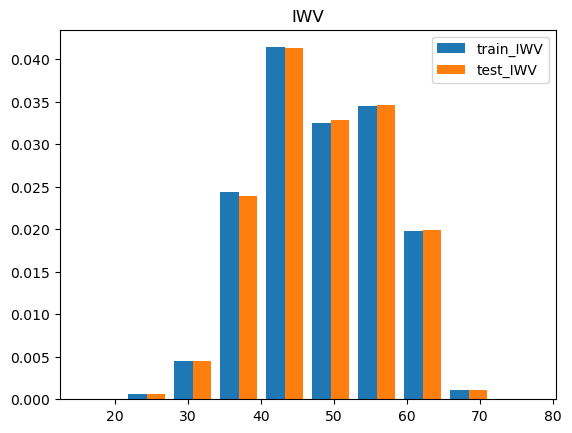

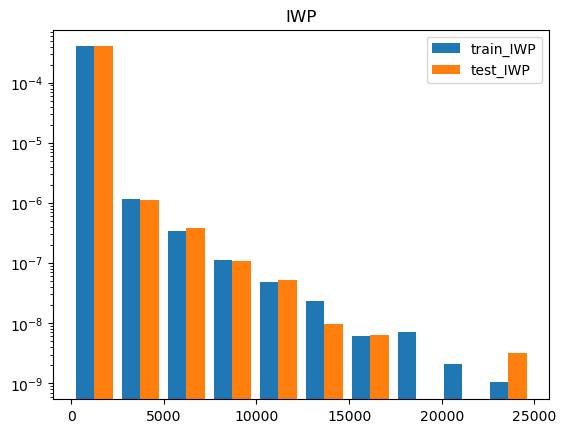

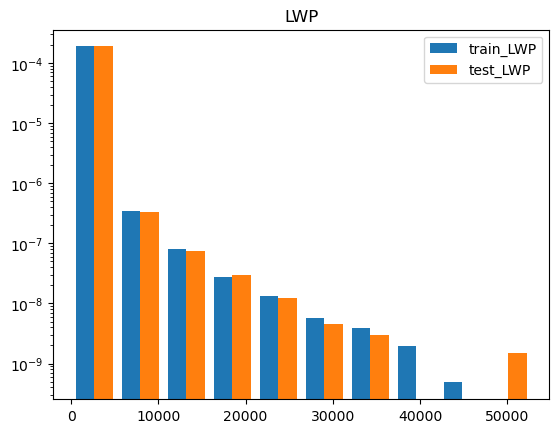

In [28]:
plt.hist([train_IWV, test_IWV],label=['train_IWV', 'test_IWV'],density=True)
plt.title('IWV')
plt.legend()
plt.show()
plt.hist([train_IWP, test_IWP],label=['train_IWP', 'test_IWP'],density=True,log=True)
plt.title('IWP')
plt.legend()
plt.show()
plt.hist([train_LWP, test_LWP],label=['train_LWP', 'test_LWP'],density=True,log=True)
plt.title('LWP')
plt.legend()
plt.show()

### Standardizing Input
##### standardize all TBs along their respective channel as a normal distribution with mean 0 and std of 1

In [11]:
def standardize_nn_training_data(TBs_train):
        
    TBs_centered = np.zeros(TBs_train.shape)
    mu_train = np.zeros(TBs_train.shape[1])
    sigma_train = np.zeros(TBs_train.shape[1])
    for channel in range(TBs_train.shape[1]):

        mu_train[channel] = np.nanmean(TBs_train[:,channel])
        sigma_train[channel] = np.nanstd(TBs_train[:,channel])   

        TBs_centered[:,channel] = (TBs_train[:,channel] - mu_train[channel])/sigma_train[channel]
        
    return TBs_centered, mu_train, sigma_train
    
def standardize_nn_input_data_v2(TBs, mu, sigma):
    
    TBs = np.asarray(TBs)
    # if single TB observation provided extend dims to 2
    if len(TBs.shape) == 1:
        TBs = TBs[np.newaxis,:]
    
    TBs_centered = np.zeros(TBs.shape)
    for channel in range(TBs.shape[1]):

        TBs_centered[:,channel] = (TBs[:,channel] - mu[channel])/sigma[channel]
    
    return TBs_centered
    

TBs_train_scaled, mu_train, sigma_train = standardize_nn_training_data(train_TB) 
TBs_test_scaled = standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 
TBs_validate_scaled = standardize_nn_input_data_v2(validate_TB,mu=mu_train,sigma=sigma_train)

### Choosing value to train : IWP, LWP or IWV
## IWP

In [12]:
train, test_TB, validate = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
train_TB=np.concatenate([train,validate])
train_IWP, test_IWP, validate_IWP = splitting_in_train_test_validate(IWP,t_steps,slices_train,slices_validate,slices_test)
train_IWP=np.concatenate([train_IWP,validate_IWP])

TBs_train_scaled, mu_train, sigma_train = standardize_nn_training_data(train_TB) 
TBs_test_scaled = standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 
TBs_validate_scaled = standardize_nn_input_data_v2(validate_TB,mu=mu_train,sigma=sigma_train)

variable= "IWP" # "LWP" # "IWV" #
train_hyd =train_IWP #Hyd to train
test_hyd=test_IWP # Hyd to test
validate_hyd=validate_IWP



#### Definition of network

In [13]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50

#### Loop over all altitudes: Compilation , Training and saving of each Network


altitude used for training: 11400


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

NameError: name 'name_pamtra_run_' is not defined

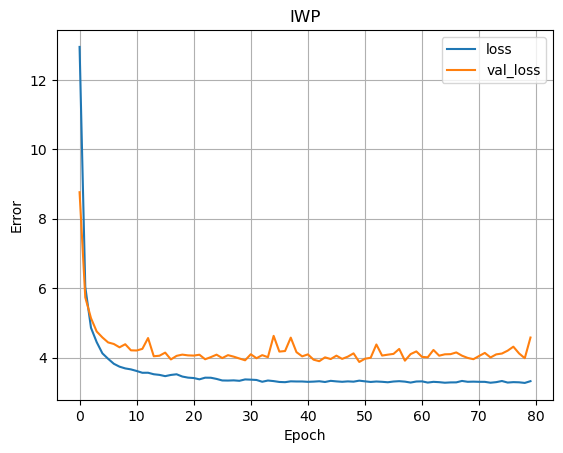

In [16]:
%%time
# define & compile nn-model for iwp with specified settings
# * 1 input layer (24 neurons) 
# * 1 hidden layer (64 neurons)
# * 1 output layer (1 neuron)
# as loop for all heights
training_version = "v1"
TBs_train=train_TB
train_hyd =train_IWP #Hyd to train
test_hyd=test_IWP # Hyd to test
validate_hyd=validate_IWP

for altitude in flight_levels:
    print("altitude used for training:", altitude)

    # compile network
    dnn_model_iwp = tf.keras.Sequential([
        tf.keras.layers.Dropout(rate=0.05, input_shape=(TBs_train.shape[1],)),
        tf.keras.layers.Dense(NR_of_NEURONS_L1,
                              input_shape=(TBs_train.shape[1],),
                              bias_initializer=BIAS_INIT,
                              kernel_initializer=WEIGHT_INIT,
                              kernel_regularizer="l2",
                              activation=ACTIVATION_HL,
                             ),
        tf.keras.layers.Dense(1,
                              activation=ACTIVATION_OP)])
    
    dnn_model_iwp.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                          loss=LOSS_FUNCTION,
                         )
    
    dnn_model_iwp.summary()

    
    
    #train network
    history = dnn_model_iwp.fit(
        TBs_train_scaled, np.sqrt(train_hyd),
        validation_split=0.2,
        #validation_data=(TBs_validate_scaled,validate_hyd),#new
        verbose=0,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)]
    )
    
    # use typhon ploting style
    #plt.style.use(ty.plots.styles.get('typhon'))
    
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    #plt.ylim(0,40)
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.grid(True)
    plt.legend()
    plt.title(variable)

    variable='IWV'

    dnn_model_iwp.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_ + {training_version}.keras')
    #save mu and sigma
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + training_version + '_v1_'+ str(altitude) +'m.npy',mu_train)
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + training_version + '_v1_'+ str(altitude) +'m.npy',sigma_train)
    if altitude == 14450:
        TBs_train=train_TB
        train_hyd =train_IWP #Hyd to train
        test_hyd

In [15]:
### LOAD MODEL
variable='IWP'
#altitude = 14450 #from prep-for-NN-training.py script
path=(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_v1.keras')
dnn_model_iwp = tf.keras.models.load_model(path,compile=False)

2025-07-30 18:18:23.874596: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### NN-IWP performance on PAMTRA test dataset

In [16]:
# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
##IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
##IWP_test_predictions_squared = IWP_test_predictions_cliped**2
IWP_test_predictions_squared =IWP_test_predictions**2

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 379us/step


In [17]:
IWP_test_predictions_squared

array([0.013, 0.045, 0.   , ..., 1.795, 0.008, 0.024],
      shape=(125208,), dtype=float32)

In [72]:
IWP_test_predictions_squared
#IWP_test_predictions

array([0.024, 0.308, 0.013, ..., 0.001, 0.003, 0.016],
      shape=(125208,), dtype=float32)

In [73]:
0.033**2

0.0010890000000000001

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2392123/59705641.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sqrt{IWP}$")


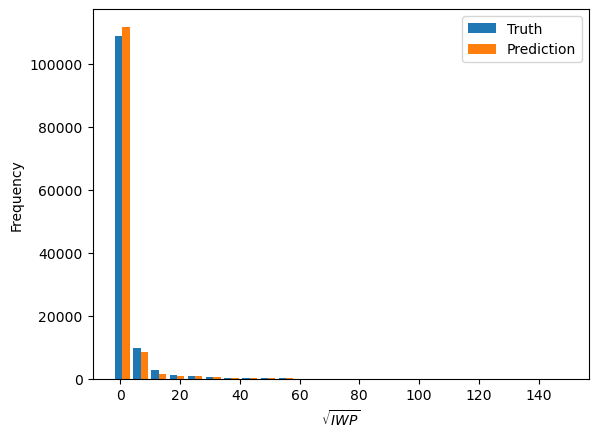

In [18]:
# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

fig, ax = plt.subplots()

labels = [
    f"Truth",
    "Prediction",
    "Prediction (cliped)"]
ax.hist(np.array([np.sqrt(test_hyd),IWP_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
#ax.text(35.,3000,"$\overline{Truth}=$"+str(np.round(np.nanmean(np.sqrt(IWP_test)),2))+"$\sqrt{g}m^{-1}$",ha="left")
#ax.text(35.,2700,"$\overline{Prediction}=$"+str(np.round(np.mean(IWP_test_predictions),2))+"$\sqrt{g}m^{-1}$",ha="left")
##ax.text(35.,2400,"$\overline{Prediction (cliped)}=$"+str(np.round(np.mean(IWP_test_predictions_cliped),2))+"$\sqrt{g}m^{-1}$",ha="left")
ax.set_xlabel("$\sqrt{IWP}$")
ax.set_ylabel("Frequency")
plt.legend()
plt.show()
#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_predictions_cliping_effect.jpg',bbox_inches='tight',dpi=200)

In [75]:
a.max()

np.float32(77.88089)

bias:  -3.67  corr:  0.97  rmse:  84.67


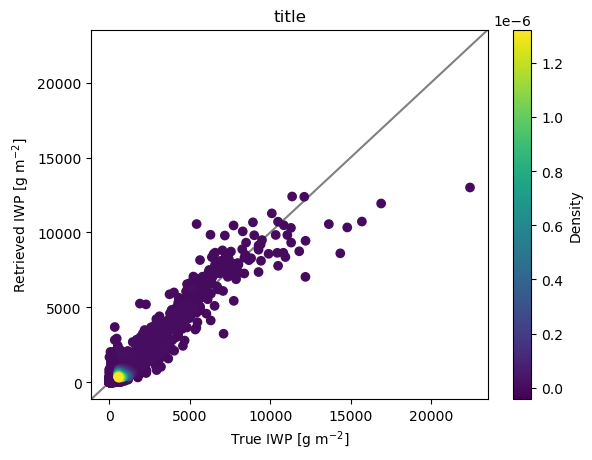

In [20]:
a = test_hyd
b = IWP_test_predictions_squared 
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]
bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)
print('bias: ',bias,' corr: ',corr,' rmse: ',rmse)
from matplotlib import cm
from scipy.interpolate import interpn
from matplotlib.colors import Normalize 
density_scatter(a,b,xlabel='True IWP [g m$^{-2}$]',ylabel='Retrieved IWP [g m$^{-2}$]' )
mi=np.min([a,b])
ma=np.max([a,b])
d=np.abs(mi-ma)*0.05
plt.xlim([mi-d,ma+d])
plt.ylim([mi-d,ma+d])
plt.show()

In [19]:
def density_scatter( x , y, ax = None, sort = True, bins = 20,title="title",xlabel="x",ylabel="y",lim=None, **kwargs )   :
  """
  Scatter plot colored by 2d histogram
  """
  
  
  if ax is None :
      fig , ax = plt.subplots()
  ax.axline((0,0),slope=1,color="grey", zorder=1)
  data , x_e, y_e = np.histogram2d( x, y, bins = bins, density = True )
  z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ) , data , np.vstack([x,y]).T , method = "splinef2d", bounds_error = False)

  #To be sure to plot all data
  z[np.where(np.isnan(z))] = 0.0

  # Sort the points by density, so that the densest points are plotted last
  if sort :
      idx = z.argsort()
      x, y, z = x[idx], y[idx], z[idx]

  ax.scatter( x, y, c=z, **kwargs )

  norm = Normalize(vmin = np.min(z), vmax = np.max(z))
  cbar = fig.colorbar(cm.ScalarMappable(norm = norm), ax=ax)
  if lim != None:
      ax.set_xlim(lim)
      ax.set_ylim(lim)
  cbar.ax.set_ylabel('Density')
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  ax.set_title(str(title))

  return ax
#test_hyd
#IWP_test_predictions_squared

In [101]:
ab = np.vstack([a,b])
# b, which is retrieveved **2 is to close to zero
c = scipy.stats.gaussian_kde(ab)

print('Variable 1 min/max:', ab[0].min(), ab[0].max())
print('Variable 2 min/max:', ab[1].min(), ab[1].max())

# Check variance
print('Variance of variable 1:', np.var(ab[0]))
print('Variance of variable 2:', np.var(ab[1]))


Variable 1 min/max: 0.0 3.2373695
Variable 2 min/max: 0.0 2.736485
Variance of variable 1: 0.21424791
Variance of variable 2: 0.18785673


/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


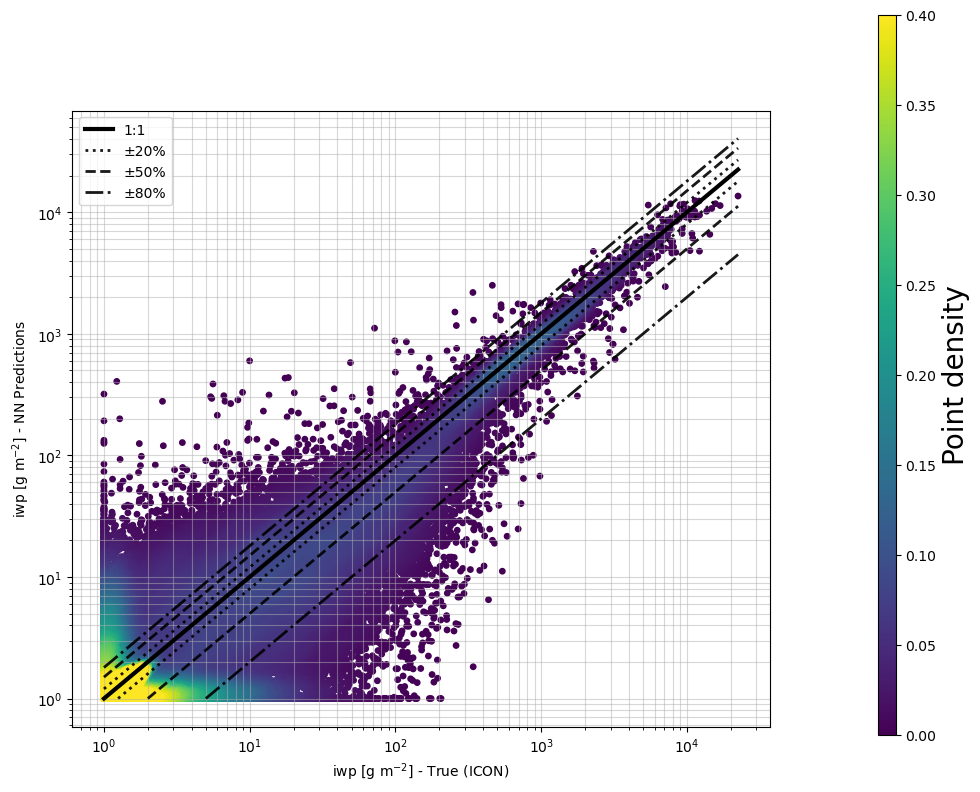

Bias: -0.04
RMSE: 0.32
Corr: 0.89


In [77]:

kind = 'log'

fig, axs = plt.subplots(figsize=(9,8))
iwp_test_predictions_squared=IWP_test_predictions_squared
if kind == 'linear':
    
    a = test_IWP
    b = iwp_test_predictions_squared
    
    a[a<1.] = 0
    b[b<1.] = 0
    
    #a[a<1.] = np.nan
    #b[b<1.] = np.nan
    
if kind == 'log':
    
    iwp_test_log = test_IWP.copy()
    iwp_test_log[iwp_test_log==0] = 10**(-16)
    iwp_test_predictions_squared_log = iwp_test_predictions_squared.copy()
    iwp_test_predictions_squared_log[iwp_test_predictions_squared_log==0] = 10**(-16)
    
    a = np.log10(iwp_test_log)
    b = np.log10(iwp_test_predictions_squared_log)
    
    a[a<0.] = 0
    b[b<0.] = 0
    
    #a[a<0.] = np.nan
    #b[b<0.] = np.nan
    
    #a = iwp_test.copy()
    #b = iwp_test_predictions_squared.copy()
    
    #a[a<1.] = 1.
    #b[b<1.] = 1.
    
if kind == 'sqrt':
    
    a = np.sqrt(test_IWP)
    b = iwp_test_predictions

nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]

maxval = max(np.max(a),np.max(b))
minval = max(np.min(a),np.min(b))
    
# Calculate the point density
ab = np.vstack([a,b])
c = scipy.stats.gaussian_kde(ab)(ab)

# Sort the points by density, so that the densest points are plotted last
idx = c.argsort()
a, b, c = a[idx], b[idx], c[idx]

bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)

axs.grid(alpha=0.5,which='both')

iwp_true = np.arange(1,np.nanmax(test_IWP),0.01)
RE_80_plus = (0.8*iwp_true)+iwp_true
RE_80_minus = (-0.8*iwp_true)+iwp_true
RE_50_plus = (0.5*iwp_true)+iwp_true
RE_50_minus = (-0.5*iwp_true)+iwp_true
RE_20_plus = (0.2*iwp_true)+iwp_true
RE_20_minus = (-0.2*iwp_true)+iwp_true
RE_20_minus[RE_20_minus<1.]=np.nan
RE_50_minus[RE_50_minus<1.]=np.nan
RE_80_minus[RE_80_minus<1.]=np.nan
  
#axs.scatter(y_test, y_test_predictions**2)
if kind == 'linear':
    sc = axs.scatter(a,b,c=c,s=5,cmap='viridis',vmin=np.min(c),vmax=0.00004)
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(iwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.5,label='±20%')
    axs.plot(iwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.5)
    axs.plot(iwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.5,label='±50%')
    axs.plot(iwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.5)
    axs.plot(iwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5,label='±80%')
    axs.plot(iwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5)
    
    axs.set_xlabel('iwp [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('iwp [g m$^{-2}$] - NN Predictions')
    axs.set_ylim(top=3200)
    axs.set_xlim(right=3200)
    
if kind == 'log':
    sc = axs.scatter(10**a,10**b,c=c,s=15,cmap='viridis',vmin=0,vmax=0.4)
    #sc = axs.scatter(a,b,c=c,s=8,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(10**0,10**maxval),np.arange(10**0,10**maxval),linewidth=3,color='black',alpha=1,label='1:1')
    #axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(iwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
    axs.plot(iwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)
    axs.plot(iwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±50%')
    axs.plot(iwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
    axs.plot(iwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9,label='±80%')
    axs.plot(iwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9)
    
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_xlabel('iwp [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('iwp [g m$^{-2}$] - NN Predictions')
    #axs.set_ylim(bottom=1)
    #axs.set_xlim(left=1)

if kind == 'sqrt':
    sc = axs.scatter(a,b,c=c,s=15,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=2,color='black',alpha=0.5)
    #axs.set_xlabel('$\sqrt{iwp}$ [$\sqrt{g}m^{-1}$] - True (ICON)')
    #axs.set_ylabel('$\sqrt{iwp}$ [$\sqrt{g}m^{-1}$] - NN predictions')
    
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Point density',size=20)
axs.legend()

#axs.text(0.02, 0.8, 'Bias: '+str(bias), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.885, 'RMSE: '+str(rmse), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.81, 'Corr: '+str(corr), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
plt.show()
print('Bias: '+str(bias))
print('RMSE: '+str(rmse))
print('Corr: '+str(corr))


Text(62.597222222222214, 0.5, 'Retrieved IWP [g m$^{-2}$]')

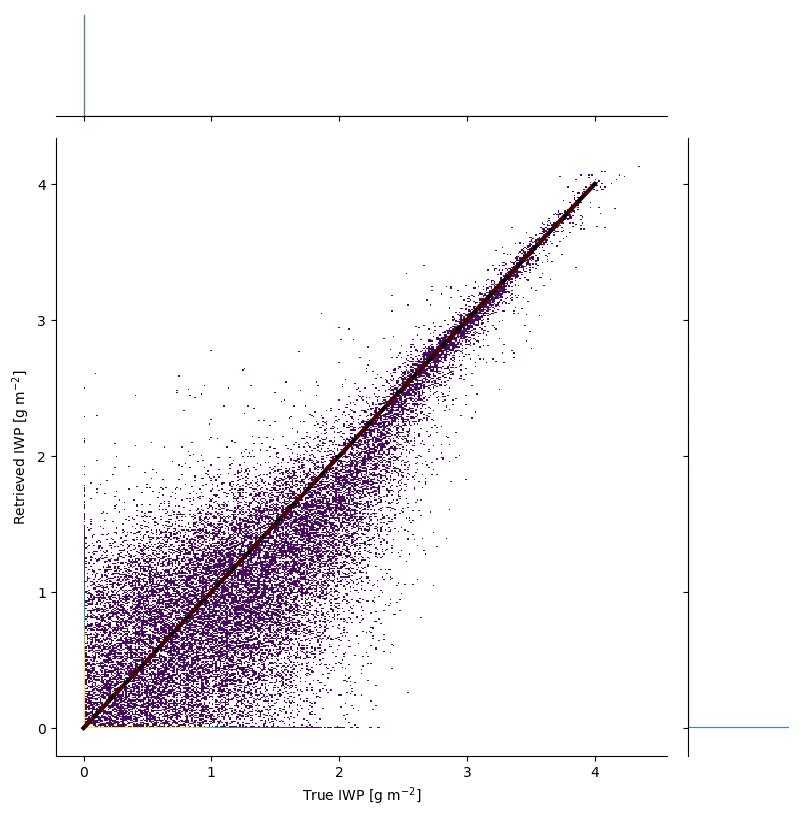

In [79]:
kind = 'log'
IWP_test=test_IWP
if kind == 'linear':
    
    a = IWP_test
    b = IWP_test_predictions_squared
    
    a[a<1.] = 0
    b[b<1.] = 0
    
    #a[a<1.] = np.nan
    #b[b<1.] = np.nan
    
if kind == 'log':
    
    IWP_test_log = IWP_test.copy()
    IWP_test_log[IWP_test_log==0] = 10**(-16)
    #IWP_test_log[IWP_test_log<1] = np.nan
    IWP_test_predictions_squared_log = IWP_test_predictions_squared.copy()
    IWP_test_predictions_squared_log[IWP_test_predictions_squared_log==0] = 10**(-16)
    #IWP_test_predictions_squared_log[IWP_test_predictions_squared_log<1] = np.nan
    
    a = np.log10(IWP_test_log)
    b = np.log10(IWP_test_predictions_squared_log)
    
    a[a<0.] = 0
    b[b<0.] = 0
    
    #a[a<0.] = np.nan
    #b[b<0.] = np.nan
    
    #a = IWP_test.copy()
    #b = IWP_test_predictions_squared.copy()
    
    #a[a<1.] = 0.
    #b[b<1.] = 0.
    
if kind == 'sqrt':
    
    a = np.sqrt(IWP_test)
    b = IWP_test_predictions
    
maxval = max(np.nanmax(a),np.nanmax(b))
    
#a[a<0.] = 0
#b[b<0.] = 0

#f, ax = plt.subplots()

#sns.set(color_codes=True)

jp = sns.jointplot(x = a, y = b,
                   kind = "hist", data = None, cmap='viridis',vmin=0, vmax=60, height=8,)
jp.ax_joint.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
#jp.ax_joint.plot(iwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
#jp.ax_joint.plot(iwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)
#jp.ax_joint.plot(iwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±50%')
#jp.ax_joint.plot(iwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
#jp.ax_joint.plot(iwp_true,RE_100_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9,label='±100%')
#jp.ax_joint.plot(iwp_true,RE_100_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9)
#jp.ax_joint.set_xlim(0,maxval)
#jp.ax_joint.set_ylim(0,maxval)
#jp.ax_joint.set_xscale('log')
#jp.ax_joint.set_yscale('log')
jp.ax_joint.plot(np.arange(0,4.5),np.arange(0,4.5),linewidth=3,linestyle='dashed',color='darkred',alpha=0.5)
jp.ax_joint.set_xlabel('True IWP [g m$^{-2}$]')
jp.ax_joint.set_ylabel('Retrieved IWP [g m$^{-2}$]')
#plt.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=2,color='black',alpha=0.5)
#plt.xscale('log')
#plt.yscale('log')

#sns.set(color_codes=False)

#plt.savefig('/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/plot')

In [14]:
sns.reset_orig

<function seaborn.rcmod.reset_orig()>

#### Saving NN-IWP model / retrieval to disk

In [14]:
dnn_model_iwp.save(f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_{altitude}m')
#dnn_model_iwp.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NN_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m')

# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
IWP_test_predictions_squared = IWP_test_predictions_cliped**2

# Saving collocated ICON data to netcdf file
filename = (f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/train_test_data_nn_24-32-1_reg_{altitude}m.nc')
ds = Dataset(filename,'w','NETCDF4')

# profile and frequency dimensions
ds.createDimension('train_cases',len(IWP_train))
ds.createDimension('test_cases',len(IWP_test))
ds.createDimension('freq',24)

# TBs
tb_train_var = ds.createVariable('tb_train','float64',('train_cases','freq'))
tb_train_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of training data set'
tb_train_var.setncattr('units','K')
tb_train_var[:,:] = TBs_train[:,:]
tb_test_var = ds.createVariable('tb_test','float64',('test_cases','freq'))
tb_test_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of test data set'
tb_test_var.setncattr('units','K')
tb_test_var[:,:] = TBs_test[:,:]

# IWP
iwp_train_var = ds.createVariable('iwp_train','float64',('train_cases'))
iwp_train_var.long_name = 'ICON simulated IWP values of training data set'
iwp_train_var.setncattr('units','g m2')
iwp_train_var[:] = IWP_train[:]
iwp_test_var = ds.createVariable('iwp_test','float64',('test_cases'))
iwp_test_var.long_name = 'ICON simulated IWP values of test data set'
iwp_test_var.setncattr('units','g m2')
iwp_test_var[:] = IWP_test[:]
iwp_retr_var = ds.createVariable('iwp_retrieved','float64',('test_cases'))
iwp_retr_var.long_name = 'Retrieved IWP values of test data set'
iwp_retr_var.setncattr('units','g m2')
iwp_retr_var[:] = IWP_test_predictions_squared[:]

# LWP
lwp_train_var = ds.createVariable('lwp','float64',('train_cases'))
lwp_train_var.long_name = 'ICON simulated LWP values of training data set'
lwp_train_var.setncattr('units','g m2')
lwp_train_var[:] = LWP_train[:]
lwp_test_var = ds.createVariable('lwp_test','float64',('test_cases'))
lwp_test_var.long_name = 'ICON simulated LWP values of test data set'
lwp_test_var.setncattr('units','g m2')
lwp_test_var[:] = LWP_test[:]

# IWV
iwv_train_var = ds.createVariable('iwv','float64',('train_cases'))
iwv_train_var.long_name = 'ICON simulated IWV values of training data set'
iwv_train_var.setncattr('units','g m2')
iwv_train_var[:] = IWV_train[:]
iwv_test_var = ds.createVariable('iwv_test','float64',('test_cases'))
iwv_test_var.long_name = 'ICON simulated IWV values of test data set'
iwv_test_var.setncattr('units','g m2')
iwv_test_var[:] = IWV_test[:]

ds.close()

INFO:tensorflow:Assets written to: /home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_12500m/assets


INFO:tensorflow:Assets written to: /home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_12500m/assets


489/489 [==============================] - 0s 495us/step
Negative predictions: 1.5 %


## IWV 

In [46]:
variable=  "IWV" #
train, test_TB, validate = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
train_TB=np.concatenate([train,validate])
train_IWV, test_IWV, validate_IWV = splitting_in_train_test_validate(IWV,t_steps,slices_train,slices_validate,slices_test)
train_IWV=np.concatenate([train_IWV,validate_IWV])

TBs_train_scaled, mu_train, sigma_train = standardize_nn_training_data(train_TB) 
TBs_test_scaled = standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 




#### Definition & compilation of network

In [47]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32 #20#
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50 #100#

In [48]:
# define & compile nn-model for iwp with specified settings
# * 1 input layer (24 neurons) 
# * 1 hidden layer (64 neurons)
# * 1 output layer (1 neuron)
TBs_train=train_TB
dnn_model_iwv = tf.keras.Sequential([
    tf.keras.layers.Dropout(rate=0.05, input_shape=(TBs_train.shape[1],)),
    tf.keras.layers.Dense(NR_of_NEURONS_L1,
                          input_shape=(TBs_train.shape[1],),
                          bias_initializer=BIAS_INIT,
                          kernel_initializer=WEIGHT_INIT,
                          kernel_regularizer="l2",
                          activation=ACTIVATION_HL,
                         ),
    tf.keras.layers.Dense(1,
                          activation=ACTIVATION_OP)])

dnn_model_iwv.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                      loss=LOSS_FUNCTION,
                     )

dnn_model_iwv.summary()

/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Training of IWV neural network

CPU times: user 9min 52s, sys: 26.4 s, total: 10min 18s
Wall time: 8min 2s


Text(0.5, 1.0, 'IWV')

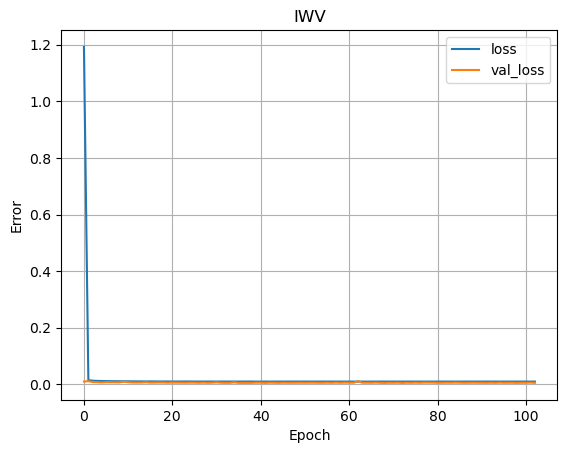

In [49]:
%%time

train_hyd =train_IWV #Hyd to train
test_hyd=test_IWV # Hyd to test
validate_hyd=validate_IWV
history = dnn_model_iwv.fit(
    TBs_train_scaled, np.sqrt(train_hyd),
    validation_split=0.2,
    #validation_data=(TBs_validate_scaled,validate_hyd),#new
    verbose=0,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True, 
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)]
)

# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
#plt.ylim(0,40)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.grid(True)
plt.legend()
plt.title('IWV')

#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_training_error_loss_24-32-1.jpg',bbox_inches='tight',dpi=200)

Text(0.5, 1.0, 'IWV')

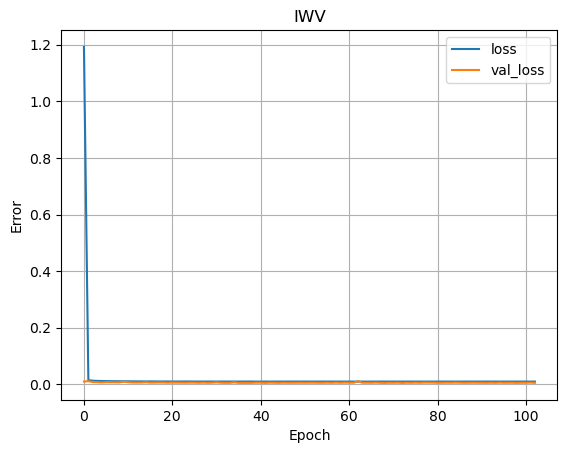

In [50]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
#plt.ylim(0,40)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.grid(True)
plt.legend()
plt.title('IWV')

In [41]:
#Or load model
variable='IWV'
#altitude = 14450 #from prep-for-NN-training.py script
path=(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_v1.keras')
#dnn_model_iwv = tf.keras.models.load_model(path,compile=False)


In [42]:
path

'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_IWV/dnn_model_IWV_24-32-1_reg_13850m_v1.keras'

### NN-IWV performance on PAMTRA test dataset

In [51]:
# predict sqrt(IWP) with neural network for given TBs
IWV_test_predictions = dnn_model_iwv.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
##IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
##IWP_test_predictions_squared = IWP_test_predictions_cliped**2
IWV_test_predictions_squared =IWV_test_predictions**2

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 381us/step


In [52]:
IWV_test_predictions

array([7.528, 7.599, 7.518, ..., 6.441, 6.441, 6.429],
      shape=(125208,), dtype=float32)

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4134557/3582528795.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sqrt{IWV}$")


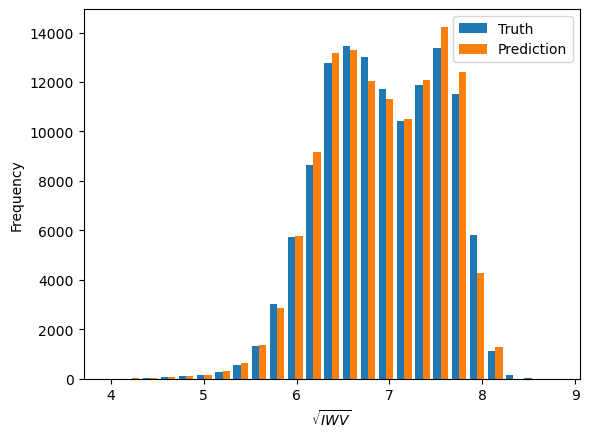

In [53]:
# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

fig, ax = plt.subplots()

labels = [
    f"Truth",
    "Prediction",
    "Prediction (cliped)"]
ax.hist(np.array([np.sqrt(test_hyd),IWV_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
#ax.text(35.,3000,"$\overline{Truth}=$"+str(np.round(np.nanmean(np.sqrt(IWP_test)),2))+"$\sqrt{g}m^{-1}$",ha="left")
#ax.text(35.,2700,"$\overline{Prediction}=$"+str(np.round(np.mean(IWP_test_predictions),2))+"$\sqrt{g}m^{-1}$",ha="left")
##ax.text(35.,2400,"$\overline{Prediction (cliped)}=$"+str(np.round(np.mean(IWP_test_predictions_cliped),2))+"$\sqrt{g}m^{-1}$",ha="left")
ax.set_xlabel("$\sqrt{IWV}$")
ax.set_ylabel("Frequency")
plt.legend()
plt.show()
#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_predictions_cliping_effect.jpg',bbox_inches='tight',dpi=200)

In [54]:
a.max()

np.float32(22425.625)

bias:  -0.11  corr:  0.99  rmse:  0.87


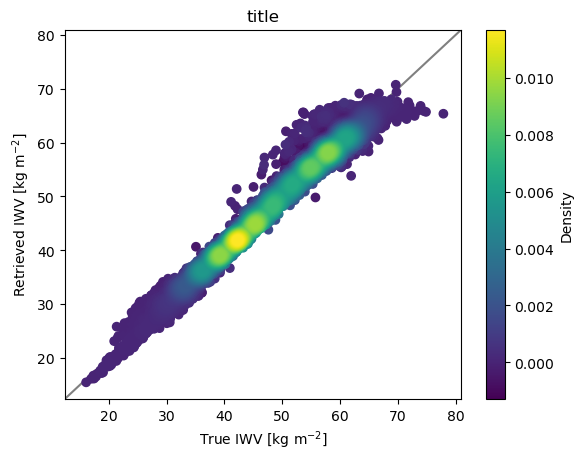

In [60]:
a = test_hyd
b = IWV_test_predictions_squared
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]
bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)
print('bias: ',bias,' corr: ',corr,' rmse: ',rmse)
from matplotlib import cm
from scipy.interpolate import interpn
from matplotlib.colors import Normalize 
density_scatter(a,b,xlabel='True IWV [kg m$^{-2}$]',ylabel='Retrieved IWV [kg m$^{-2}$]' )
mi=np.min([a,b])
ma=np.max([a,b])
d=np.abs(mi-ma)*0.05
plt.xlim([mi-d,ma+d])
plt.ylim([mi-d,ma+d])
plt.show()

#### Load true and predicted hydrometeors so that error calculation is possilbe

In [6]:
variable= 'IWV'
training_version='v1'
altitude = 14450
train_hyd=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_train_{variable}.npy')
test_hyd=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_test_{variable}.npy')
#TODO load model and predict 
a = test_hyd
b = IWV_test_predictions_squared
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]    

In [62]:
np.logspace(1, 200, num_bins + 1)*10

array([1.000e+002, 8.913e+011, 7.943e+021, 7.079e+031, 6.310e+041,
       5.623e+051, 5.012e+061, 4.467e+071, 3.981e+081, 3.548e+091,
       3.162e+101, 2.818e+111, 2.512e+121, 2.239e+131, 1.995e+141,
       1.778e+151, 1.585e+161, 1.413e+171, 1.259e+181, 1.122e+191,
       1.000e+201])

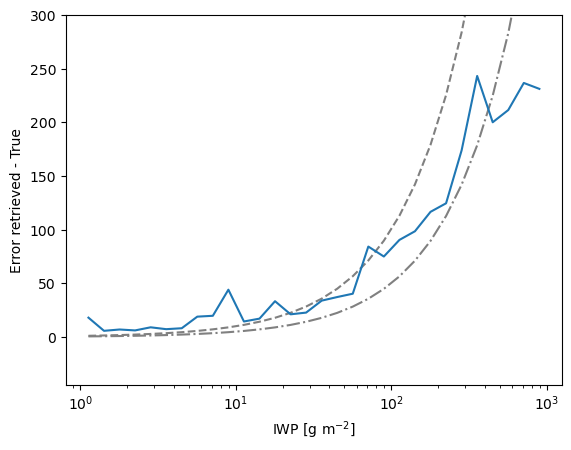

In [75]:
# TEST run with IWP
variable='IWP'
a = test_hyd #True
b = IWP_test_predictions_squared #predicted
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]



# Define bin edges (e.g., 10 bins)
num_bins = 20

if variable == 'IWV':
    bins = np.linspace(np.min(a), np.max(a), num_bins + 1)
else: 
    bin_max = 3 # max(a) #set to number of interest or maybe with if variable == 'IWP':
    bin_min = 0
    num_bins = (bin_max - bin_min) *10 
    bins  = np.logspace(bin_min, bin_max, num_bins + 1)
# 

# Digitize 'a' to find out which bin each value belongs to
bin_indices = np.digitize(a, bins)

# Initialize arrays to hold results
bin_centers = (bins[:-1] + bins[1:]) / 2
b_error = np.empty(num_bins)
rel_100 = np.empty(num_bins)
# Calculate error (e.g., standard deviation) of 'b' within each bin
for i in range(1, num_bins + 1):
    # Find indices of data points in the current bin
    in_bin = bin_indices == i
    #error as rmse between true and predicted # like in marek s paper
    targets= a[in_bin]
    predictions= b[in_bin]
    b_error[i-1]=np.sqrt(((predictions - targets) ** 2).mean())
    ## Calculate standard deviation of 'b' for these points
    #b_error[i - 1] = np.std(b[in_bin])
    #rel_100=
# Plot
plt.plot(bin_centers,bin_centers,linestyle='--',color='grey') #relative erorr 100 percent
plt.plot(bin_centers,0.5*bin_centers,linestyle='-.',color='grey') #relative erorr 100 percent
plt.plot(bin_centers,b_error)

#plt.errorbar(bin_centers, np.zeros_like(bin_centers), yerr=b_error, fmt='o', capsize=5)
plt.xscale('log')
if variable == 'IWV':
    plt.xlabel(variable+'[kg m$^{-2}$]')
else:
    plt.xlabel(variable+' [g m$^{-2}$]')
    plt.ylim(top=300)

plt.ylabel('Error retrieved - True')
#plt.title('Error of b within each a bin')
plt.show()

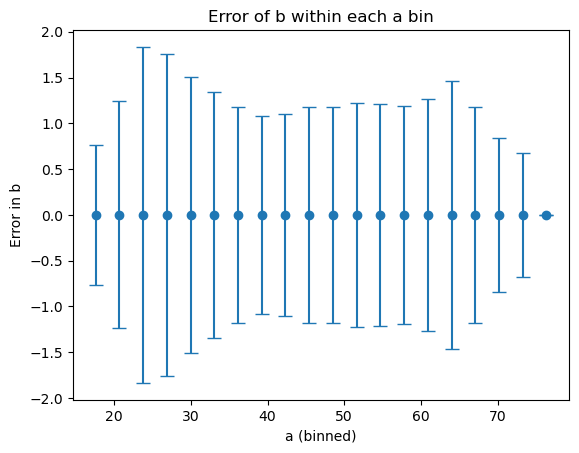

In [64]:
# PROBABLY ONLY GOOD FOR IWP AND LWP full of erros
# Example data
#a = np.random.rand(1000) * 10  # replace with your data
#b = np.random.rand(1000) * 20  # replace with your data

# Define bin edges (e.g., 10 bins)
num_bins = 20
bins  =np.linspace(np.min(a), np.max(a), num_bins + 1)# np.logspace(np.log10(min(data)), np.log10(max(data)), num_bins + 1)
# 

# Digitize 'a' to find out which bin each value belongs to
bin_indices = np.digitize(a, bins)

# Initialize arrays to hold results
bin_centers = (bins[:-1] + bins[1:]) / 2
b_error = np.empty(num_bins)

# Calculate error (e.g., standard deviation) of 'b' within each bin
for i in range(1, num_bins + 1):
    # Find indices of data points in the current bin
    in_bin = bin_indices == i
    # Calculate standard deviation of 'b' for these points
    b_error[i - 1] = np.std(b[in_bin])

# Plot
plt.errorbar(bin_centers, np.zeros_like(bin_centers), yerr=b_error, fmt='o', capsize=5)
#plt.xscale('log')
plt.xlabel('a (binned)')
plt.ylabel('Error in b')
plt.title('Error of b within each a bin')
plt.show()

## Saving IWV NN

In [163]:
variable='IWV'
#altitude = 14450 #from prep-for-NN-training.py script
#dnn_model_iwp.save(f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_{altitude}m')
dnn_model_iwv.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m.keras')
#save mu and sigma
np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy',mu_train)
np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy',sigma_train)

## Application Halo flights 
#### maybe bring to different notebook

In [15]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
ds_iwv_kw=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_iwv_kw.nc")
ds_sondes=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_sondes.nc")
ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 

target_date ='2024-08-11'# '2024-09-16'#'2024-09-19'#'2024-09-26'#'2024-08-11'
def sel_target_date(target_date,ds):
  target_datetime = pd.to_datetime(target_date)
  if 'time' in ds.coords:
     ds_filtered=ds.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))
  elif 'sonde_time' in ds.coords:
    ds_filtered = ds.where(ds['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)
  else:
    print("please check dimension names for time dimension")
  return ds_filtered
#ds_HAMP=sel_target_date(target_date,ds_HAMP) 
#ds_sondes_f=sel_target_date(target_date,ds_sondes)
#ds_halo_altitude=sel_target_date(target_date,ds_halo_altitude)

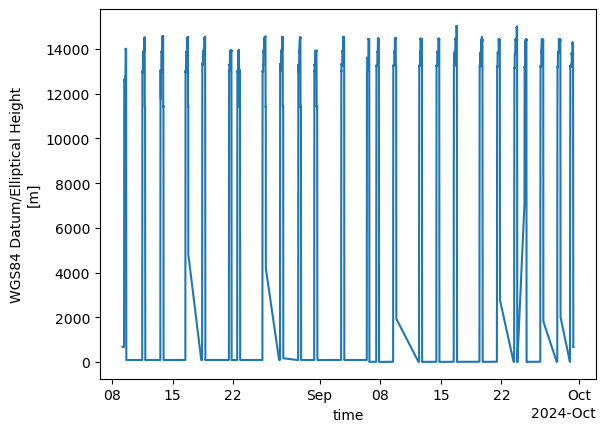

In [16]:
#ds_halo_altitude['alt'].plot()
ds_HAMP['plane_altitude'].plot()

In [17]:
variable='IWV'
print(ds_HAMP.frequency)
ds_hamp=ds_HAMP

excluded_frequencies = ds_hamp.frequency.where(ds_hamp.frequency!=184.81, drop=True)

# Step 2: Filter the dataset to exclude the specified frequency
ds_hamp = ds_hamp.sel(frequency=excluded_frequencies)
print(ds_hamp.TBs)
#ds_HAMP_scaled_array=[]
#for i in range(len(flight_levels)):
#
#    ds_HAMP_scaled_array.append(standardize_nn_input_data_v2(np.asarray(ds_hamp.TBs.values),mu=mu_train,sigma=sigma_train))
#IWV_halo_predictions = dnn_model_iwv.predict(ds_HAMP_scaled)[:,0]**2    

def find_nearest_value(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def retrieve_IWV(TBs,altitudes):
    
    levels = np.array([find_nearest_value(flight_levels,altitudes[i]) for i in range(len(altitudes))])
    IWV = np.zeros(len(TBs))
    IWV[:] = np.nan
    for i in range(len(flight_levels)):
        altitude =flight_levels[i]
        if len(levels[levels==altitude]) != 0:
            print(f"Retrieving from {altitude} ({len(levels[levels==altitude])} TBs)")
            #hier modul load
            mu_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy')
            sigma_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy')
            
            ds_hamp_scaled=standardize_nn_input_data_v2(np.asarray(ds_hamp.TBs[levels==altitude].values),mu=mu_train,sigma=sigma_train)
            #print('trying to mini',np.asarray(ds_hamp.TBs[levels==altitude].values).shape)
            #print('shape hampscaled',ds_HAMP_scaled.shape)
            dnn_model_iwv = tf.keras.models.load_model(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m.keras',compile=False)
            IWV[np.where(levels==altitude)] = dnn_model_iwv.predict(ds_hamp_scaled)[:,0]**2
    # Indicate the fraction of negative predictions (possible as the sqrt of IWP is retrieved).
    print("")
    print((len(IWV[IWV<0])/len(IWV)),"% negative predictions (=clipped to 0).")
    print("")
    # If negative IWP values exist, they are clipped to 0.
    IWV[IWV<0] = 0.
    # clip everything below 10500km
    IWV[altitudes<=10500] =np.nan
    levels[altitudes<=10500] =0

    return IWV, levels 
IWV, levels =retrieve_IWV(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values)

<xarray.DataArray 'frequency' (frequency: 25)> Size: 100B
array([ 22.24,  23.04,  23.84,  25.44,  26.24,  27.84,  31.4 ,  50.3 ,  51.76,
        52.8 ,  53.75,  54.94,  56.66,  58.  ,  90.  , 120.15, 121.05, 122.95,
       127.25, 183.91, 184.81, 185.81, 186.81, 188.31, 190.81], dtype=float32)
Coordinates:
  * frequency  (frequency) float32 100B 22.24 23.04 23.84 ... 186.8 188.3 190.8
<xarray.DataArray 'TBs' (time: 3750412, frequency: 24)> Size: 360MB
[90009888 values with dtype=float32]
Coordinates:
  * frequency  (frequency) float32 96B 22.24 23.04 23.84 ... 186.8 188.3 190.8
  * time       (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... 2024-09-30T...
Attributes:
    long_name:  TB Map
    units:      K
Retrieving from 11400 (1136192 TBs)
35506/35506 ━━━━━━━━━━━━━━━━━━━━ 13s 369us/step
Retrieving from 12650 (83445 TBs)
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step
Retrieving from 13000 (200682 TBs)
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 2s 390us/step
Retrieving from 13250 (545792 TBs)
170

In [20]:
ds_hamp

<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 24)
Coordinates:
  * frequency             (frequency) float32 96B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables:
    AziAng                (time, frequency) float32 360MB ...
    ElAng                 (time, frequency) float32 360MB ...
    RF                    (time, frequency) float64 720MB ...
    TBs                   (time, frequency) float32 360MB nan nan ... nan nan
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    mask_amplifier_fault  (time, frequency) int64 720MB ...
    mask_sea_land         (time) int64 30MB ...
    plane_altitude        (time) float64 30MB 679.7 679.7 679.7 ... 681.0 681.0
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV                   (time) float64 30MB nan nan nan nan ... nan nan nan
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

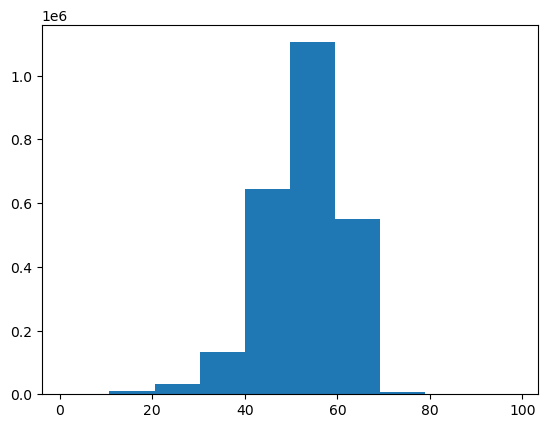

In [21]:
IWV.shape
ds_hamp['IWV']= (('time',), IWV)
plt.hist(ds_hamp.IWV)
#ds_hamp.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1_alllevels.nc ')

In [205]:
#altitudes=ds_hamp['plane_altitude']
#TBs=ds_hamp['TBs']
#levels = np.array([find_nearest_value(flight_levels,altitudes[i]) for i in range(len(altitudes))])
#IWV = np.zeros(len(TBs))
#IWV[:] = np.nan
print(levels[110000:])

[14450 14450 14450 ... 11400 11400 11400]


In [14]:
dnn_model_iwv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
print(ds_HAMP_scaled.shape,TBs_test_scaled.shape)

(3750412, 24) (125208, 24)


In [16]:
ds_HAMP_scaled.shape
IWV_halo_predictions = dnn_model_iwv.predict(ds_HAMP_scaled)[:,0]




IWV_halo_predictions_squared =IWV_halo_predictions**2

117201/117201 ━━━━━━━━━━━━━━━━━━━━ 45s 386us/step


In [41]:
# put predictions back into HAMP Dataset
print(len(IWV_halo_predictions_squared),ds_HAMP)
ds_HAMP['IWV_myret']= (('time',), IWV_halo_predictions_squared)
#ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1.nc ')

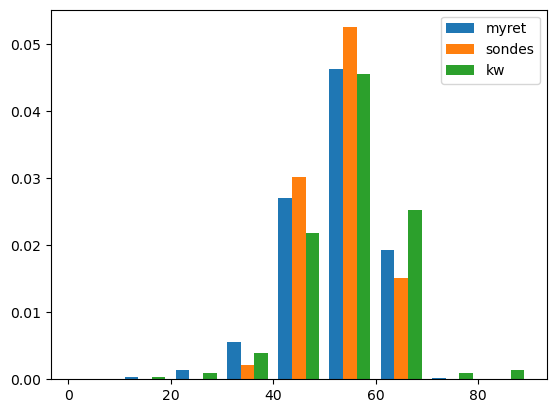

In [19]:
bins = np.arange(0,100,10)

#plt.hist(,bins=bins) # is this first retrival?? with nice data 
#IWV_halo_predictions_squared
plt.hist([ds_hamp.IWV,ds_sondes.iwv,ds_iwv_kw.IWV],bins=bins,label=['myret','sondes','kw'],density=True)#,fill=False)#,color='g')
#plt.hist(,bins=bins,fill=False)
#ds_sondes
plt.legend()

## Plot for one flight


<xarray.Dataset> Size: 4MB
Dimensions:                (sonde: 49, altitude: 1460)
Coordinates:
    aircraft_latitude      (sonde) float32 196B 8.289 2.823 ... 16.99 17.13
    aircraft_longitude     (sonde) float32 196B -26.38 -27.41 ... -24.43 -24.81
    aircraft_msl_altitude  (sonde) float32 196B 1.297e+04 ... 1.142e+04
  * altitude               (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    sonde_time             (sonde) datetime64[ns] 392B 2024-08-11T13:20:01 .....
Dimensions without coordinates: sonde
Data variables: (12/23)
    bin_average_time       (sonde, altitude) datetime64[ns] 572kB 2024-08-11T...
    flight_id              (sonde) object 392B 'HALO-20240811a' ... 'HALO-202...
    iwv                    (sonde) float32 196B 54.21 40.56 40.42 ... 49.03 47.1
    lat                    (sonde, altitude) float32 286kB 8.286 8.286 ... nan
    lon                    (sonde, altitude) float32 286kB -26.4 -26.4 ... nan
    p                      (sonde, altitude) float32 286kB 

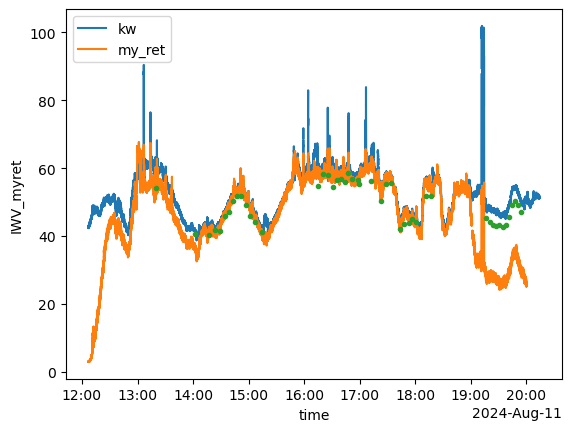

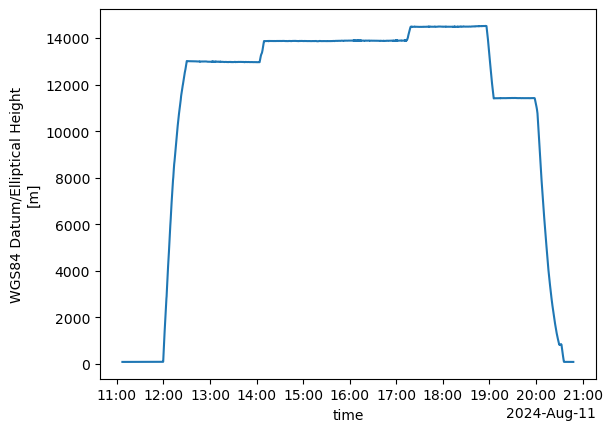

In [39]:
import pandas as pd
# selecting only one day:
# Define the target date
target_date = '2024-08-11'#'2024-09-16'#'2024-09-19'#'2024-09-26'#
target_datetime = pd.to_datetime(target_date)
ds_filtered = ds_sondes.where(ds_sondes['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)

"""

# Convert the target date to a pandas datetime object
target_datetime = pd.to_datetime(target_date)

# Filter the xarray dataset
# We need to select the time dimension based on the target date
filtered_ds_sondes = ds_sondes.sel(sonde_time=slice(target_datetime, target_datetime + pd.Timedelta(days=3)))
"""
ds_sondes_f = ds_sondes.where(ds_sondes['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)

ds_HAMP_f=ds_HAMP.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))

ds_iwv_kw_f=ds_iwv_kw.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))
# Now filtered_ds_sondes contains only the entries for August 9, 2024
print(ds_sondes_f)
ds_iwv_kw_f.IWV.plot(label='kw')
ds_HAMP_f.IWV_myret.plot(label='my_ret')
plt.plot(ds_sondes_f.sonde_time,ds_sondes_f.iwv,'.')
plt.legend()
plt.show()
ds_halo_altitude.alt.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1))).plot()
plt.show()

In [ ]:

# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
IWP_test_predictions_squared = IWP_test_predictions_cliped**2

# Saving collocated ICON data to netcdf file
filename = (f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/train_test_data_nn_24-32-1_reg_{altitude}m.nc')
ds = Dataset(filename,'w','NETCDF4')

# profile and frequency dimensions
ds.createDimension('train_cases',len(IWP_train))
ds.createDimension('test_cases',len(IWP_test))
ds.createDimension('freq',24)

# TBs
tb_train_var = ds.createVariable('tb_train','float64',('train_cases','freq'))
tb_train_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of training data set'
tb_train_var.setncattr('units','K')
tb_train_var[:,:] = TBs_train[:,:]
tb_test_var = ds.createVariable('tb_test','float64',('test_cases','freq'))
tb_test_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of test data set'
tb_test_var.setncattr('units','K')
tb_test_var[:,:] = TBs_test[:,:]

# IWP
iwp_train_var = ds.createVariable('iwp_train','float64',('train_cases'))
iwp_train_var.long_name = 'ICON simulated IWP values of training data set'
iwp_train_var.setncattr('units','g m2')
iwp_train_var[:] = IWP_train[:]
iwp_test_var = ds.createVariable('iwp_test','float64',('test_cases'))
iwp_test_var.long_name = 'ICON simulated IWP values of test data set'
iwp_test_var.setncattr('units','g m2')
iwp_test_var[:] = IWP_test[:]
iwp_retr_var = ds.createVariable('iwp_retrieved','float64',('test_cases'))
iwp_retr_var.long_name = 'Retrieved IWP values of test data set'
iwp_retr_var.setncattr('units','g m2')
iwp_retr_var[:] = IWP_test_predictions_squared[:]

# LWP
lwp_train_var = ds.createVariable('lwp','float64',('train_cases'))
lwp_train_var.long_name = 'ICON simulated LWP values of training data set'
lwp_train_var.setncattr('units','g m2')
lwp_train_var[:] = LWP_train[:]
lwp_test_var = ds.createVariable('lwp_test','float64',('test_cases'))
lwp_test_var.long_name = 'ICON simulated LWP values of test data set'
lwp_test_var.setncattr('units','g m2')
lwp_test_var[:] = LWP_test[:]

# IWV
iwv_train_var = ds.createVariable('iwv','float64',('train_cases'))
iwv_train_var.long_name = 'ICON simulated IWV values of training data set'
iwv_train_var.setncattr('units','g m2')
iwv_train_var[:] = IWV_train[:]
iwv_test_var = ds.createVariable('iwv_test','float64',('test_cases'))
iwv_test_var.long_name = 'ICON simulated IWV values of test data set'
iwv_test_var.setncattr('units','g m2')
iwv_test_var[:] = IWV_test[:]

ds.close()

## LWP 

In [10]:
variable=  "LWP" #



#### Definition & compilation of network

In [11]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50

In [12]:
# define & compile nn-model for lwp with specified settings
# * 1 input layer (24 neurons) 
# * 1 hidden layer (64 neurons)
# * 1 output layer (1 neuron)
TBs_train=train_TB
dnn_model_lwp = tf.keras.Sequential([
    tf.keras.layers.Dropout(rate=0.05, input_shape=(TBs_train.shape[1],)),
    tf.keras.layers.Dense(NR_of_NEURONS_L1,
                          input_shape=(TBs_train.shape[1],),
                          bias_initializer=BIAS_INIT,
                          kernel_initializer=WEIGHT_INIT,
                          kernel_regularizer="l2",
                          activation=ACTIVATION_HL,
                         ),
    tf.keras.layers.Dense(1,
                          activation=ACTIVATION_OP)])

dnn_model_lwp.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                      loss=LOSS_FUNCTION,
                     )

dnn_model_lwp.summary()

/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-05-20 13:58:31.068954: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Training of LWP neural network

CPU times: user 6min 20s, sys: 18.4 s, total: 6min 39s
Wall time: 4min 49s


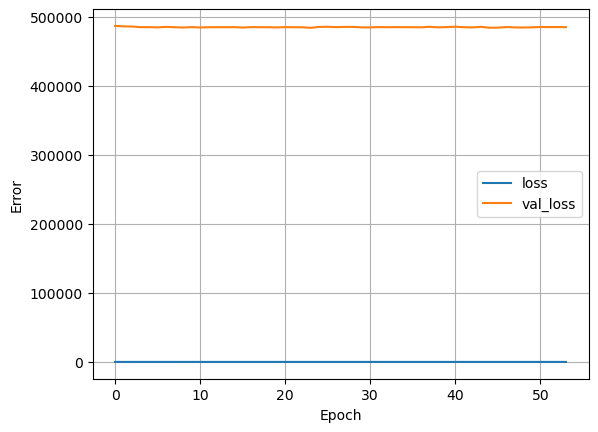

In [13]:
%%time

train_hyd =train_LWP #Hyd to train
test_hyd=test_LWP # Hyd to test
validate_hyd=validate_LWP
history = dnn_model_lwp.fit(
    TBs_train_scaled, np.sqrt(train_hyd),
    validation_split=0.2,
    validation_data=(TBs_validate_scaled,validate_hyd),#new
    verbose=0,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)]
)

# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
#plt.ylim(0,40)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.grid(True)
plt.legend()

#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_training_error_loss_24-32-1.jpg',bbox_inches='tight',dpi=200)

### NN-LWP performance on PAMTRA test dataset

In [14]:
# predict sqrt(IWP) with neural network for given TBs
LWP_test_predictions = dnn_model_lwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
##IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
##IWP_test_predictions_squared = IWP_test_predictions_cliped**2
LWP_test_predictions_squared =LWP_test_predictions**2

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 411us/step


In [15]:
LWP_test_predictions

array([ 1.113,  4.532,  1.976, ..., 25.402,  4.566,  0.344],
      shape=(125208,), dtype=float32)

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_581651/1336751582.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sqrt{LWP}$")


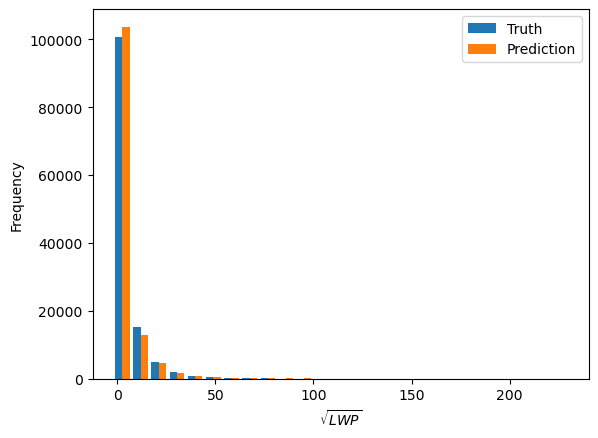

In [23]:
# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

fig, ax = plt.subplots()

labels = [
    f"Truth",
    "Prediction",
    "Prediction (cliped)"]
ax.hist(np.array([np.sqrt(test_hyd),LWP_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
#ax.text(35.,3000,"$\overline{Truth}=$"+str(np.round(np.nanmean(np.sqrt(IWP_test)),2))+"$\sqrt{g}m^{-1}$",ha="left")
#ax.text(35.,2700,"$\overline{Prediction}=$"+str(np.round(np.mean(IWP_test_predictions),2))+"$\sqrt{g}m^{-1}$",ha="left")
##ax.text(35.,2400,"$\overline{Prediction (cliped)}=$"+str(np.round(np.mean(IWP_test_predictions_cliped),2))+"$\sqrt{g}m^{-1}$",ha="left")
ax.set_xlabel("$\sqrt{LWP}$")
ax.set_ylabel("Frequency")
plt.legend()
plt.show()
#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_predictions_cliping_effect.jpg',bbox_inches='tight',dpi=200)

In [17]:
a.max()

np.int64(32)

bias:  0.29  corr:  0.87  rmse:  321.76


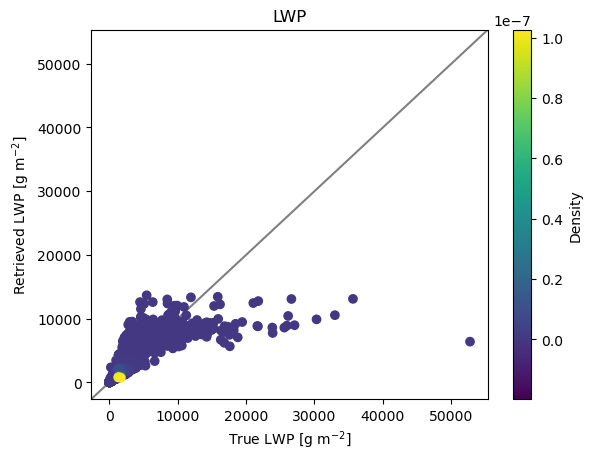

In [22]:
a = test_hyd
b = LWP_test_predictions_squared
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]
bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)
print('bias: ',bias,' corr: ',corr,' rmse: ',rmse)
from matplotlib import cm
from scipy.interpolate import interpn
from matplotlib.colors import Normalize 
density_scatter(a,b,xlabel='True LWP [g m$^{-2}$]',ylabel='Retrieved LWP [g m$^{-2}$]',title='LWP' )

mi=np.min([a,b])
ma=np.max([a,b])
d=np.abs(mi-ma)*0.05
plt.xlim([mi-d,ma+d])
plt.ylim([mi-d,ma+d])
plt.show()

/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


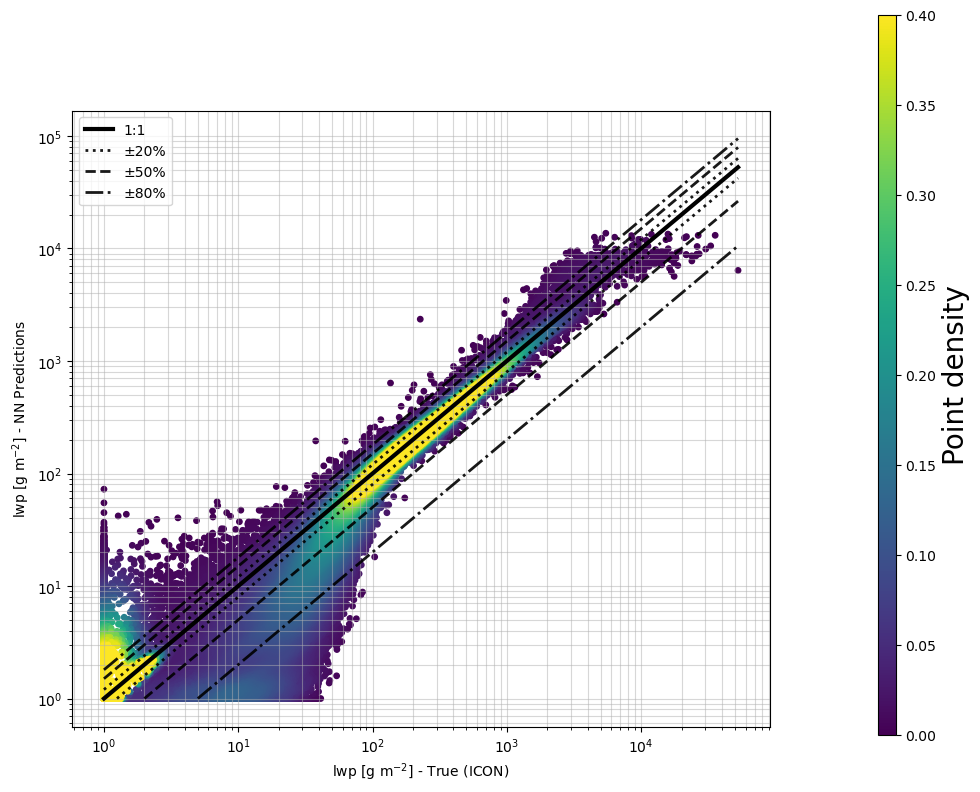

Bias: -0.04
RMSE: 0.31
Corr: 0.95


In [19]:

kind = 'log'

fig, axs = plt.subplots(figsize=(9,8))

if kind == 'linear':
    
    a = test_LWP
    b = LWP_test_predictions_squared
    
    a[a<1.] = 0
    b[b<1.] = 0
    
    #a[a<1.] = np.nan
    #b[b<1.] = np.nan
    
if kind == 'log':
    
    LWP_test_log = test_LWP.copy()
    LWP_test_log[LWP_test_log==0] = 10**(-16)
    LWP_test_predictions_squared_log = LWP_test_predictions_squared.copy()
    LWP_test_predictions_squared_log[LWP_test_predictions_squared_log==0] = 10**(-16)
    
    a = np.log10(LWP_test_log)
    b = np.log10(LWP_test_predictions_squared_log)
    
    a[a<0.] = 0
    b[b<0.] = 0
    
    #a[a<0.] = np.nan
    #b[b<0.] = np.nan
    
    #a = lwp_test.copy()
    #b = lwp_test_predictions_squared.copy()
    
    #a[a<1.] = 1.
    #b[b<1.] = 1.
    
if kind == 'sqrt':
    
    a = np.sqrt(test_LWP)
    b = LWP_test_predictions

nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]

maxval = max(np.max(a),np.max(b))
minval = max(np.min(a),np.min(b))
    
# Calculate the point density
ab = np.vstack([a,b])
c = scipy.stats.gaussian_kde(ab)(ab)

# Sort the points by density, so that the densest points are plotted last
idx = c.argsort()
a, b, c = a[idx], b[idx], c[idx]

bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)

axs.grid(alpha=0.5,which='both')

lwp_true = np.arange(1,np.nanmax(test_LWP),0.01)
RE_80_plus = (0.8*lwp_true)+lwp_true
RE_80_minus = (-0.8*lwp_true)+lwp_true
RE_50_plus = (0.5*lwp_true)+lwp_true
RE_50_minus = (-0.5*lwp_true)+lwp_true
RE_20_plus = (0.2*lwp_true)+lwp_true
RE_20_minus = (-0.2*lwp_true)+lwp_true
RE_20_minus[RE_20_minus<1.]=np.nan
RE_50_minus[RE_50_minus<1.]=np.nan
RE_80_minus[RE_80_minus<1.]=np.nan
  
#axs.scatter(y_test, y_test_predictions**2)
if kind == 'linear':
    sc = axs.scatter(a,b,c=c,s=5,cmap='viridis',vmin=np.min(c),vmax=0.00004)
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(lwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.5,label='±20%')
    axs.plot(lwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.5)
    axs.plot(lwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.5,label='±50%')
    axs.plot(lwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.5)
    axs.plot(lwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5,label='±80%')
    axs.plot(lwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5)
    
    axs.set_xlabel('lwp [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('lwp [g m$^{-2}$] - NN Predictions')
    axs.set_ylim(top=3200)
    axs.set_xlim(right=3200)
    
if kind == 'log':
    sc = axs.scatter(10**a,10**b,c=c,s=15,cmap='viridis',vmin=0,vmax=0.4)
    #sc = axs.scatter(a,b,c=c,s=8,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(10**0,10**maxval),np.arange(10**0,10**maxval),linewidth=3,color='black',alpha=1,label='1:1')
    #axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(lwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
    axs.plot(lwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)
    axs.plot(lwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±50%')
    axs.plot(lwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
    axs.plot(lwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9,label='±80%')
    axs.plot(lwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9)
    
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_xlabel('lwp [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('lwp [g m$^{-2}$] - NN Predictions')
    #axs.set_ylim(bottom=1)
    #axs.set_xlim(left=1)

if kind == 'sqrt':
    sc = axs.scatter(a,b,c=c,s=15,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=2,color='black',alpha=0.5)
    #axs.set_xlabel('$\sqrt{lwp}$ [$\sqrt{g}m^{-1}$] - True (ICON)')
    #axs.set_ylabel('$\sqrt{lwp}$ [$\sqrt{g}m^{-1}$] - NN predictions')
    
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Point density',size=20)
axs.legend()

#axs.text(0.02, 0.8, 'Bias: '+str(bias), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.885, 'RMSE: '+str(rmse), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.81, 'Corr: '+str(corr), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
plt.show()
print('Bias: '+str(bias))
print('RMSE: '+str(rmse))
print('Corr: '+str(corr))


In [81]:

#LWP_test[LWP_test<1] = np.nan
#LWP_test_predictions_squared[LWP_test_predictions_squared<1] = np.nan

LWP_test_predictions_squared_clipped = LWP_test_predictions_squared.copy()
LWP_test_predictions_squared_clipped[LWP_test_predictions_squared_clipped<1.]=1.

LWP_test_clipped = test_LWP.copy()
LWP_test_clipped[LWP_test_clipped<1.]=1.

n_normed_ICON_clipped, ICON_zeros, bins  = src.normed_log10_pdf_v0(LWP_test_clipped,bin_nr=30)
n_normed_NN_clipped, NN_zeros, _ = src.normed_log10_pdf_v0(LWP_test_predictions_squared_clipped,bin_nr=30)
n_normed_ICON, bins  = src.normed_log10_pdf(LWP_test_clipped,bin_nr=30)
n_normed_NN, _ = src.normed_log10_pdf(LWP_test_predictions_squared_clipped,bin_nr=30)

# use typhon ploting style
plt.style.use(ty.plots.styles.get('typhon'))

fig, axs = plt.subplots()

axs.plot(10**bins[1:],n_normed_ICON_clipped,linewidth=3,color='black',label='Test data set - clipped')
axs.plot(10**bins[1:],n_normed_NN_clipped,linewidth=3,color='black',linestyle='dashed',label='NN Predictions - clipped')
#axs.plot(10**bins[1:],n_normed_ICON,linewidth=3,color='red',label='Test data set')
#axs.plot(10**bins[1:],n_normed_NN,linewidth=3,color='red',linestyle='dashed',label='NN Predictions')
axs.set_xscale('log')
#axs.set_yscale('log')
axs.legend()
axs.set_ylabel('Relative frequency')
axs.set_xlabel('LWP [g m$^{-2}$]')
xmin,xmax = axs.get_xlim()
plt.show()

NameError: name 'src' is not defined

## Trying cross validation


In [16]:
#now with IWP
train, test_TB, validate = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
train_TB=np.concatenate([train,validate])
train_IWV, test_IWV, validate_IWV = splitting_in_train_test_validate(IWP,t_steps,slices_train,slices_validate,slices_test)
train_IWV=np.concatenate([train_IWV,validate_IWV])


In [17]:
test_IWV


array([0.   , 1.106, 0.   , ..., 0.   , 0.   , 0.   ],
      shape=(125208,), dtype=float32)

In [18]:
train_TB



array([[217.944, 215.182, 204.779, ..., 261.834, 265.71 , 269.654],
       [222.221, 219.773, 209.997, ..., 260.751, 263.625, 267.087],
       [217.855, 214.733, 204.231, ..., 261.097, 265.704, 270.727],
       ...,
       [203.133, 201.984, 195.335, ..., 271.555, 275.955, 278.752],
       [197.637, 196.179, 188.6  , ..., 271.921, 275.17 , 281.497],
       [197.247, 195.72 , 187.817, ..., 271.973, 275.895, 278.713]],
      shape=(391275, 24))

In [19]:
train_IWV




array([ 28.427, 114.83 ,  61.231, ...,   0.   ,   0.   ,   0.   ],
      shape=(391275,), dtype=float32)

In [20]:
test_TB

array([[215.073, 212.538, 202.713, ..., 263.007, 267.71 , 273.198],
       [216.851, 214.499, 204.258, ..., 263.47 , 267.622, 273.132],
       [214.513, 212.279, 202.253, ..., 264.379, 268.59 , 274.381],
       ...,
       [204.75 , 203.691, 197.598, ..., 271.545, 274.547, 281.257],
       [197.643, 196.271, 188.479, ..., 271.887, 276.576, 280.939],
       [198.339, 196.717, 188.919, ..., 271.281, 276.509, 280.748]],
      shape=(125208, 24))

In [21]:
validate_IWV


array([ 0.   , 75.499,  2.741, ...,  0.   ,  0.   ,  0.   ],
      shape=(125208,), dtype=float32)

In [22]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32 #20#
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 200#1000
BATCH_SIZE = 50 #100#

In [23]:
from sklearn.model_selection import KFold
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dropout(rate=0.05, input_shape=(train_TB.shape[1],)),
        tf.keras.layers.Dense(NR_of_NEURONS_L1,
                              bias_initializer=BIAS_INIT,
                              kernel_initializer=WEIGHT_INIT,
                              kernel_regularizer="l2",
                              activation=ACTIVATION_HL),
        tf.keras.layers.Dense(1, activation=ACTIVATION_OP)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss=LOSS_FUNCTION,metrics=['mse'] )
    return model

### Implement cross-validation



In [24]:
%%time
# Define the number of folds
PATIENCE = 10
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
print('start')
# Arrays to store results
val_scores = []

for train_index, val_index in kf.split(train_TB):
    print(train_index, val_index)
    # Split data
    TBs_train_cv, TBs_val_cv = train_TB[train_index], train_TB[val_index]
    IWV_train_cv, IWV_val_cv = train_IWV[train_index], train_IWV[val_index]

    # Standardize training data
    TBs_train_scaled, mu, sigma = standardize_nn_training_data(TBs_train_cv)
    # Standardize validation data using training parameters
    TBs_val_scaled = standardize_nn_input_data_v2(TBs_val_cv, mu, sigma)

    # Create a new model instance
    model = create_model()

    # Train the model
    history = model.fit(
        TBs_train_scaled, IWV_train_cv,
        validation_data=(TBs_val_scaled, IWV_val_cv),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        shuffle=True,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True)]
    )

    # Evaluate validation performance
    val_loss = model.evaluate(TBs_val_scaled, IWV_val_cv, verbose=0)
    val_scores.append(val_loss)

# Compute average validation loss
average_val_loss = np.mean(val_scores)
print(f"Average validation loss across {num_folds} folds: {average_val_loss}")

start
[     0      1      3 ... 391269 391270 391273] [     2      7     11 ... 391271 391272 391274]


/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-05-28 16:28:16.412182: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[     1      2      3 ... 391272 391273 391274] [     0      6     12 ... 391265 391266 391270]
[     0      2      3 ... 391271 391272 391274] [     1      4     10 ... 391254 391258 391273]
[     0      1      2 ... 391272 391273 391274] [     3      8      9 ... 391261 391263 391268]
[     0      1      2 ... 391272 391273 391274] [     5     13     15 ... 391264 391267 391269]
Average validation loss across 5 folds: 14275.033984375
CPU times: user 1h 53min 33s, sys: 4min 47s, total: 1h 58min 21s
Wall time: 1h 28min 31s


### Final model training:

Epoch 1/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 719us/step - loss: 146502.7031 - mse: 146502.5000
Epoch 2/200
 216/7826 ━━━━━━━━━━━━━━━━━━━━ 5s 704us/step - loss: 185815.9375 - mse: 185815.4375

/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mse
  current = self.get_monitor_value(logs)


7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 718us/step - loss: 143935.8125 - mse: 143935.3281
Epoch 3/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 720us/step - loss: 124845.3906 - mse: 124844.8047
Epoch 4/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 722us/step - loss: 123357.6406 - mse: 123357.0547
Epoch 5/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 723us/step - loss: 117773.6328 - mse: 117773.1328
Epoch 6/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 718us/step - loss: 105603.8438 - mse: 105603.2812
Epoch 7/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 719us/step - loss: 101810.4688 - mse: 101809.9609
Epoch 8/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 722us/step - loss: 97533.5391 - mse: 97532.9609
Epoch 9/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 721us/step - loss: 94411.3281 - mse: 94410.8359
Epoch 10/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 717us/step - loss: 83154.9219 - mse: 83154.4141
Epoch 11/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 714us/step - loss: 85652.4688 - mse: 85651.9766
Epoch 12/200
7826/7826 ━━━━━━━━━━━━━━━━━━━━ 6s 716us/step 

KeyError: 'val_loss'

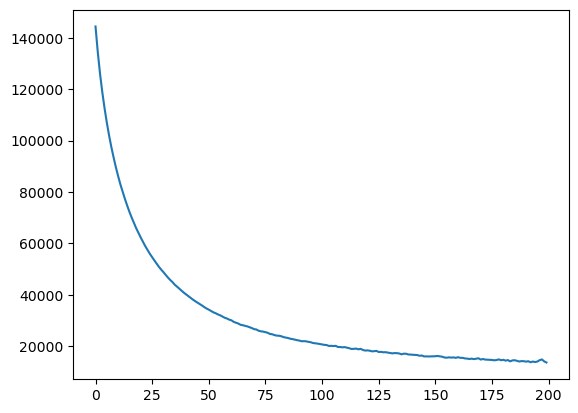

In [25]:
%%time
# Standardize entire training data
TBs_scaled_final, mu_final, sigma_final = standardize_nn_training_data(train_TB)
model_final = create_model()
history_final = model_final.fit(
    TBs_scaled_final, train_IWV,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    shuffle=True,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=30, restore_best_weights=True)]
)
plt.plot(history_final.history['loss'], label='loss')
plt.plot(history_final.history['val_loss'], label='val_loss')
#plt.ylim(0,40)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.grid(True)
plt.legend()
plt.title('IWV')


Text(0.5, 1.0, 'IWV')

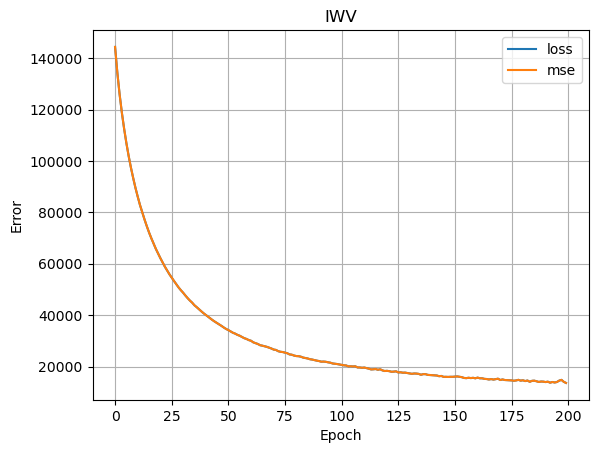

In [27]:
plt.plot(history_final.history['loss'], label='loss')
plt.plot(history_final.history['mse'], label='mse')
#plt.ylim(0,4)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.grid(True)
plt.legend()
plt.title('IWV')


### Testing

 124/3913 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step 

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1727769/3069598075.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sqrt{IWV}$")


3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 389us/step


/tmp/ipykernel_1727769/3069598075.py:16: RuntimeWarning: invalid value encountered in sqrt
  ax.hist(np.array([np.sqrt(test_IWV),np.sqrt(IWV_test_predictions)]).T,bins=25,label=labels)#,IWP_test_predictions_cliped


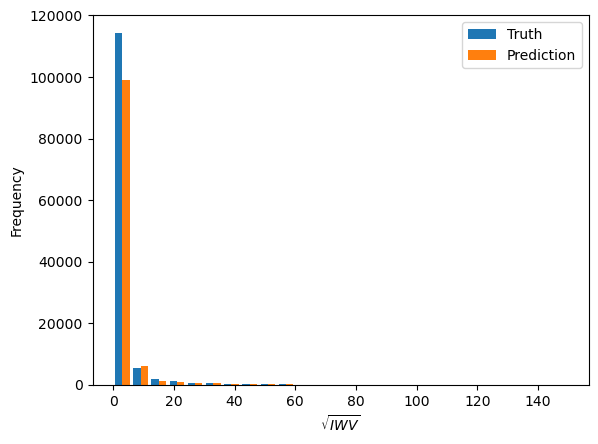

bias:  -0.47  corr:  0.97  rmse:  97.64


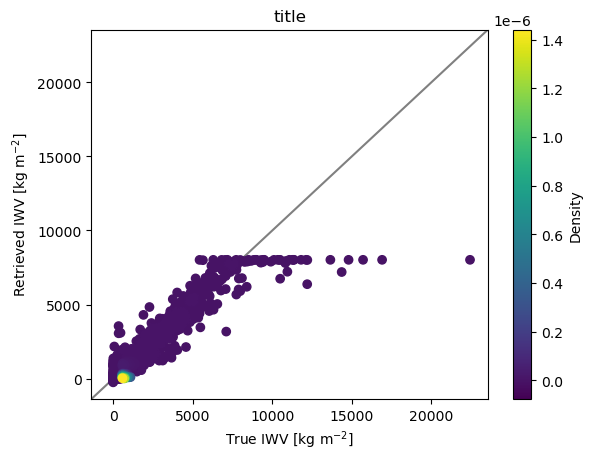

In [28]:
TBs_test_scaled=standardize_nn_input_data_v2(test_TB, mu_final, sigma_final)
IWV_test_predictions = model_final.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
##IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
##IWP_test_predictions_squared = IWP_test_predictions_cliped**2
IWV_test_predictions_squared =IWV_test_predictions**2


fig, ax = plt.subplots()

labels = [
    f"Truth",
    "Prediction",
    "Prediction (cliped)"]
ax.hist(np.array([np.sqrt(test_IWV),np.sqrt(IWV_test_predictions)]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
#ax.text(35.,3000,"$\overline{Truth}=$"+str(np.round(np.nanmean(np.sqrt(IWP_test)),2))+"$\sqrt{g}m^{-1}$",ha="left")
#ax.text(35.,2700,"$\overline{Prediction}=$"+str(np.round(np.mean(IWP_test_predictions),2))+"$\sqrt{g}m^{-1}$",ha="left")
##ax.text(35.,2400,"$\overline{Prediction (cliped)}=$"+str(np.round(np.mean(IWP_test_predictions_cliped),2))+"$\sqrt{g}m^{-1}$",ha="left")
ax.set_xlabel("$\sqrt{IWV}$")
ax.set_ylabel("Frequency")
plt.legend()
plt.show()


a = test_IWV
b = IWV_test_predictions#_squared
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]
bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)
print('bias: ',bias,' corr: ',corr,' rmse: ',rmse)
from matplotlib import cm
from scipy.interpolate import interpn
from matplotlib.colors import Normalize 
density_scatter(a,b,xlabel='True IWV [kg m$^{-2}$]',ylabel='Retrieved IWV [kg m$^{-2}$]' )
mi=np.min([a,b])
ma=np.max([a,b])
d=np.abs(mi-ma)*0.05
plt.xlim([mi-d,ma+d])
plt.ylim([mi-d,ma+d])
plt.show()

/tmp/ipykernel_1727769/1017357293.py:26: RuntimeWarning: invalid value encountered in log10
  b = np.log10(LWP_test_predictions_squared_log)


KeyboardInterrupt: 

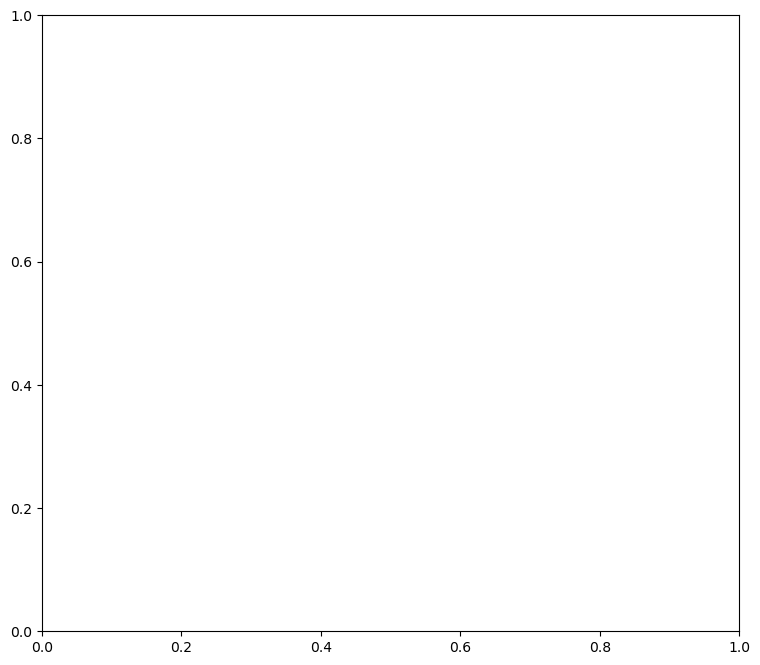

In [29]:
test_LWP = test_IWV
LWP_test_predictions_squared = IWV_test_predictions
kind = 'log'

fig, axs = plt.subplots(figsize=(9,8))

if kind == 'linear':
    
    a = test_LWP
    b = LWP_test_predictions_squared
    
    a[a<1.] = 0
    b[b<1.] = 0
    
    #a[a<1.] = np.nan
    #b[b<1.] = np.nan
    
if kind == 'log':
    
    LWP_test_log = test_LWP.copy()
    LWP_test_log[LWP_test_log==0] = 10**(-16)
    LWP_test_predictions_squared_log = LWP_test_predictions_squared.copy()
    LWP_test_predictions_squared_log[LWP_test_predictions_squared_log==0] = 10**(-16)
    
    a = np.log10(LWP_test_log)
    b = np.log10(LWP_test_predictions_squared_log)
    
    a[a<0.] = 0
    b[b<0.] = 0
    
    #a[a<0.] = np.nan
    #b[b<0.] = np.nan
    
    #a = lwp_test.copy()
    #b = lwp_test_predictions_squared.copy()
    
    #a[a<1.] = 1.
    #b[b<1.] = 1.
    
if kind == 'sqrt':
    
    a = np.sqrt(test_LWP)
    b = LWP_test_predictions

nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]

maxval = max(np.max(a),np.max(b))
minval = max(np.min(a),np.min(b))
    
# Calculate the point density
ab = np.vstack([a,b])
c = scipy.stats.gaussian_kde(ab)(ab)

# Sort the points by density, so that the densest points are plotted last
idx = c.argsort()
a, b, c = a[idx], b[idx], c[idx]

bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)

axs.grid(alpha=0.5,which='both')

lwp_true = np.arange(1,np.nanmax(test_LWP),0.01)
RE_80_plus = (0.8*lwp_true)+lwp_true
RE_80_minus = (-0.8*lwp_true)+lwp_true
RE_50_plus = (0.5*lwp_true)+lwp_true
RE_50_minus = (-0.5*lwp_true)+lwp_true
RE_20_plus = (0.2*lwp_true)+lwp_true
RE_20_minus = (-0.2*lwp_true)+lwp_true
RE_20_minus[RE_20_minus<1.]=np.nan
RE_50_minus[RE_50_minus<1.]=np.nan
RE_80_minus[RE_80_minus<1.]=np.nan
  
#axs.scatter(y_test, y_test_predictions**2)
if kind == 'linear':
    sc = axs.scatter(a,b,c=c,s=5,cmap='viridis',vmin=np.min(c),vmax=0.00004)
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(lwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.5,label='±20%')
    axs.plot(lwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.5)
    axs.plot(lwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.5,label='±50%')
    axs.plot(lwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.5)
    axs.plot(lwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5,label='±80%')
    axs.plot(lwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5)
    
    axs.set_xlabel('lwp [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('lwp [g m$^{-2}$] - NN Predictions')
    axs.set_ylim(top=3200)
    axs.set_xlim(right=3200)
    
if kind == 'log':
    sc = axs.scatter(10**a,10**b,c=c,s=15,cmap='viridis',vmin=0,vmax=0.4)
    #sc = axs.scatter(a,b,c=c,s=8,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(10**0,10**maxval),np.arange(10**0,10**maxval),linewidth=3,color='black',alpha=1,label='1:1')
    #axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(lwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
    axs.plot(lwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)
    axs.plot(lwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±50%')
    axs.plot(lwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
    axs.plot(lwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9,label='±80%')
    axs.plot(lwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9)
    
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_xlabel('lwp [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('lwp [g m$^{-2}$] - NN Predictions')
    #axs.set_ylim(bottom=1)
    #axs.set_xlim(left=1)

if kind == 'sqrt':
    sc = axs.scatter(a,b,c=c,s=15,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=2,color='black',alpha=0.5)
    #axs.set_xlabel('$\sqrt{lwp}$ [$\sqrt{g}m^{-1}$] - True (ICON)')
    #axs.set_ylabel('$\sqrt{lwp}$ [$\sqrt{g}m^{-1}$] - NN predictions')
    
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Point density',size=20)
axs.legend()

#axs.text(0.02, 0.8, 'Bias: '+str(bias), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.885, 'RMSE: '+str(rmse), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.81, 'Corr: '+str(corr), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
plt.show()
print('Bias: '+str(bias))
print('RMSE: '+str(rmse))
print('Corr: '+str(corr))


# Training all heights

<string>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\s'
<string>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_159319/2899460846.py:252: SyntaxWarning: invalid escape sequence '\{'
  ax.set_xlabel(f"$\sqrt\{{variable}}$")
/tmp/ipykernel_159319/2899460846.py:252: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel(f"$\sqrt\{{variable}}$")


['/home/u/u301032/lib/python', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python312.zip', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/lib-dynload', '', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/setuptools/_vendor', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/']
altitude used for training: 11400
shape (391275, 24) (391275,)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_17 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 392us/step


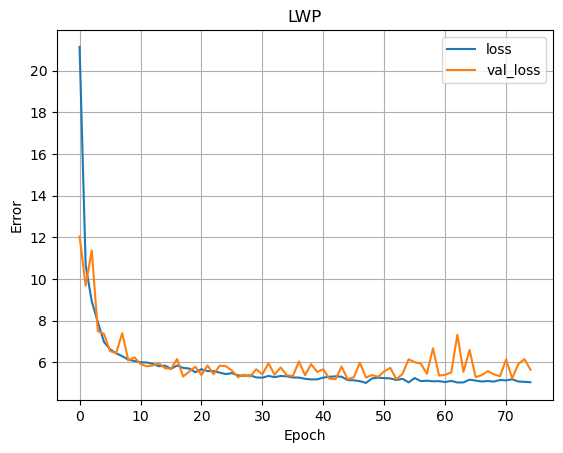

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 11400 m has been saved.
altitude used for training: 12650
shape (391275, 24) (391275,)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_18 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 444us/step


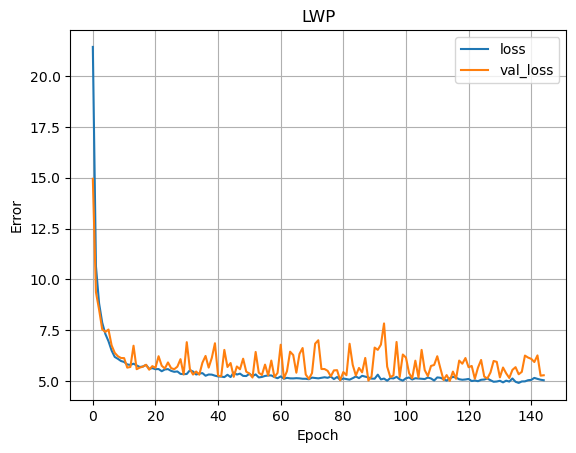

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 12650 m has been saved.
altitude used for training: 13000
shape (391275, 24) (391275,)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_19 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 386us/step


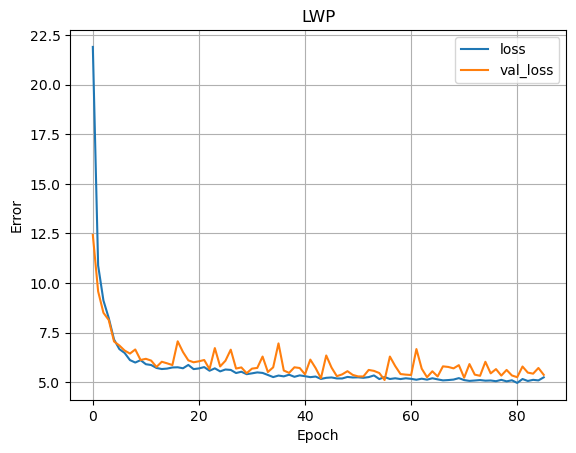

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 13000 m has been saved.
altitude used for training: 13250
shape (391275, 24) (391275,)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_20 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 398us/step


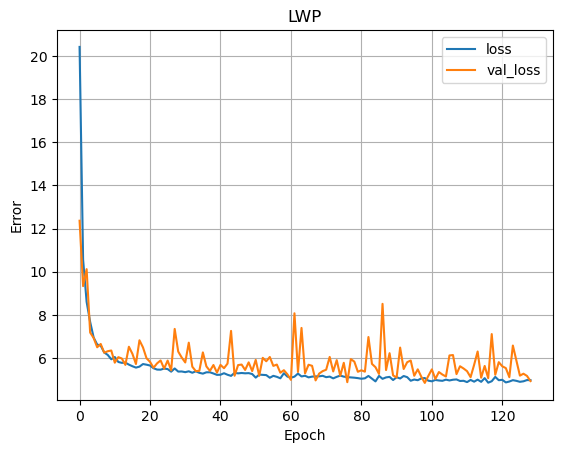

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 13250 m has been saved.
altitude used for training: 13600
shape (391275, 24) (391275,)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_21 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 395us/step


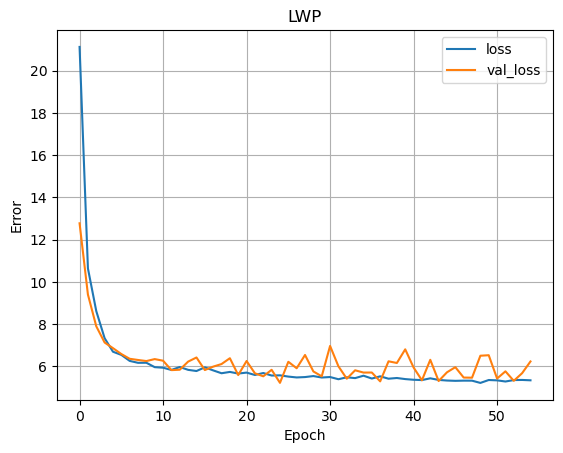

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 13600 m has been saved.
altitude used for training: 13850
shape (391275, 24) (391275,)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_22 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 412us/step


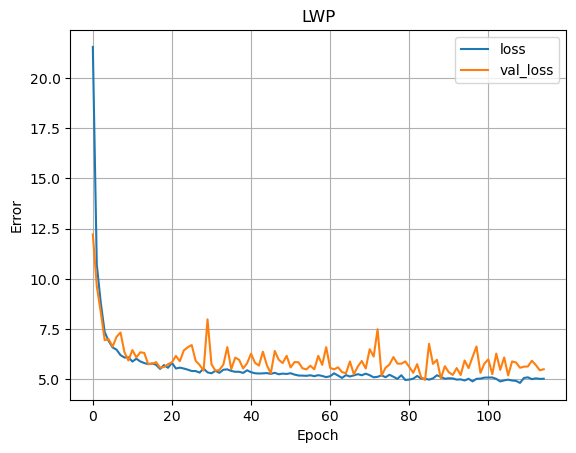

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 13850 m has been saved.
altitude used for training: 14450
shape (391275, 24) (391275,)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_23 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 398us/step


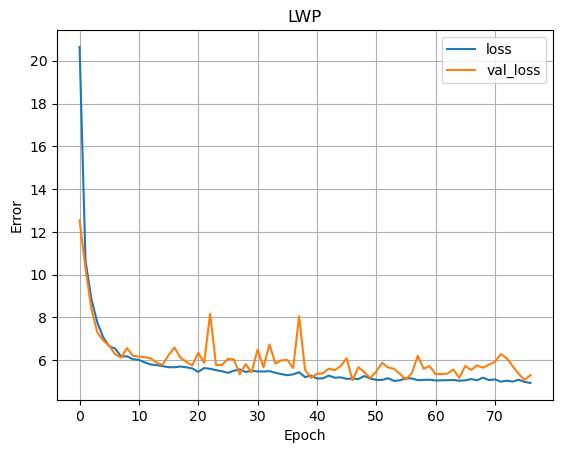

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 14450 m has been saved.
Training and Test data for 14450 m has been saved.
altitude used for training: 15000
shape (391275, 24) (391275,)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_24 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 404us/step


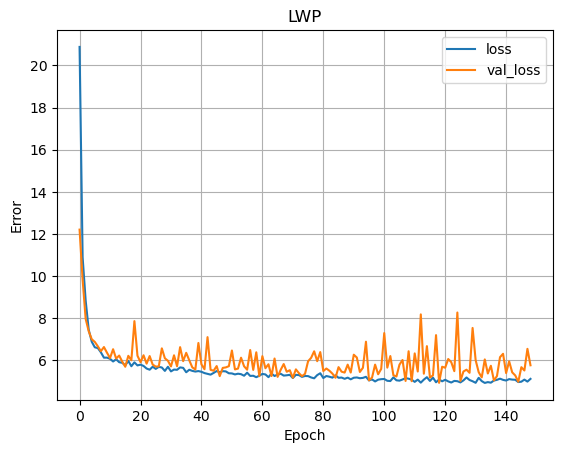

ValueError: 
\sqrt\{variable}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

NN for 15000 m has been saved.


In [4]:
"""
Training of Neural Network

This script trains the Neural Network for all hights and all hydrometeors.

 Here one can enter the findings from from NN-development.ipnyb
 """


#%%
import tensorflow as tf
#import levenberg_marquardt as lm
import scipy.stats
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import seaborn as sns
from glob import glob
import xarray as xr
#import typhon as ty
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/')
print(sys.path)
#import src

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)


#%% PARAMETERS

variable =   'LWP' # 'IWV' #'IWP' #
training_version = "v1.2"
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
flight_levels =[11400,12650,13000,13250,13600,13850,14450,15000	]






# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50



#%% LOAD PREPROCESSED TRANING DATA
data=[]
names=[ 'IWV', 'IWP', 'LWP','t_steps','cell_selection']
for i in range(len(names)):
    data.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_' + names[i] + '.npy'))
IWV, IWP, LWP,t_steps,cell_selection =data
IWP=1000*IWP
LWP=1000*LWP
IWP[IWP<1]=0.
LWP[LWP<1]=0.
TBs_array=[]
mu_array=[]
sigma_array=[]

#for altitude in flight_levels:
#    TBs_array.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy'))






#%% Functions
### Standardizing Input
##### standardize all TBs along their respective channel as a normal distribution with mean 0 and std of 1
def standardize_nn_training_data(TBs_train):
        
    TBs_centered = np.zeros(TBs_train.shape)
    mu_train = np.zeros(TBs_train.shape[1])
    sigma_train = np.zeros(TBs_train.shape[1])
    for channel in range(TBs_train.shape[1]):

        mu_train[channel] = np.nanmean(TBs_train[:,channel])
        sigma_train[channel] = np.nanstd(TBs_train[:,channel])   

        TBs_centered[:,channel] = (TBs_train[:,channel] - mu_train[channel])/sigma_train[channel]
        
    return TBs_centered, mu_train, sigma_train
    
def standardize_nn_input_data_v2(TBs, mu, sigma):
    
    TBs = np.asarray(TBs)
    # if single TB observation provided extend dims to 2
    if len(TBs.shape) == 1:
        TBs = TBs[np.newaxis,:]
    
    TBs_centered = np.zeros(TBs.shape)
    for channel in range(TBs.shape[1]):

        TBs_centered[:,channel] = (TBs[:,channel] - mu[channel])/sigma[channel]
    
    return TBs_centered


def splitting_in_train_test_validate(A,t_steps,slices_train,slices_validate,slices_test):    
    # Splits in timesteps
    x=np.arange(0,A.shape[0]+1,A.shape[0]/len(t_steps))
    x=x.astype(int)
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_train])
    train=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_validate])
    validate=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_test])
    test=  A[indexes]
    
    return train,test,validate

a=np.arange(1,33,4)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_validate=np.asarray(l)    
a=np.arange(3,33,4)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_test=np.asarray(l)   
a=np.arange(0,33,2)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_train=np.asarray(l)    


#%%
def array_for_variable(v):
    match v:
        case 'IWP':
            return IWP
        case 'IWV':
            return IWV
        case 'LWP':
            return LWP  
hyd = array_for_variable(variable)       

for altitude in flight_levels:

    train_hyd, test_hyd, validate_hyd = splitting_in_train_test_validate(hyd,t_steps,slices_train,slices_validate,slices_test)
    train_hyd=np.concatenate([train_hyd, validate_hyd])

    TBs=np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy')
    ## Filter for unrealistic BTs missing and determine calculation of flight level
    TB_input_vector=TBs
    # Only necessary if one wants to exclude certain frequencies.
    TB_input_vector = np.concatenate((
            TB_input_vector[:,0:7], # K-Band
            TB_input_vector[:,7:14], # V-Band
            TB_input_vector[:,14:15], # W-Band
            TB_input_vector[:,15:19], # F-Band
            TB_input_vector[:,19:]), # G-Band
            axis=1)
    TB_input_vector.shape

    if (len(t_steps)*len(cell_selection)!=(TB_input_vector.shape[0])):
        print("Shape of TB does not match cell and time steps. Please check.")

        """
        # exclude profiles with unrealistic pamtra simulations
        TBs[TBs[:,20]<230] = np.nan   # TODO what are in our case unrealistic values?
        TB_input_vector = TBs[~np.isnan(TBs).any(axis=1),:] #TODO: count NANs. If NAN do not just drop , as index would get messed up
        IWP = IWP[~np.isnan(TBs).any(axis=1)]
        LWP = LWP[~np.isnan(TBs).any(axis=1)]
        IWV = IWV[~np.isnan(TBs).any(axis=1)]
        """
        if np.count_nonzero(np.isnan(TBs)) > 0:
            print("NaN values in Brightnesstemperature array. This may influence the rest of the Retrievaldeveloment, as they are not being filtered.")
    train_TB, test_TB, validate_TB = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
    train_TB=np.concatenate([train_TB, validate_TB])

    TBs_train_scaled, mu_train, sigma_train = standardize_nn_training_data(train_TB) 
    TBs_test_scaled = standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 
    TBs_validate_scaled = standardize_nn_input_data_v2(validate_TB,mu=mu_train,sigma=sigma_train)

    print("altitude used for training:", altitude)
    print('shape',TBs_train_scaled.shape, np.sqrt(train_hyd).shape)
    # compile network
    dnn_model_hyd = tf.keras.Sequential([
        tf.keras.layers.Dropout(rate=0.05, input_shape=(train_TB.shape[1],)),
        tf.keras.layers.Dense(NR_of_NEURONS_L1,
                              input_shape=(train_TB.shape[1],),
                              bias_initializer=BIAS_INIT,
                              kernel_initializer=WEIGHT_INIT,
                              kernel_regularizer="l2",
                              activation=ACTIVATION_HL,
                             ),
        tf.keras.layers.Dense(1,
                              activation=ACTIVATION_OP)])
    
    dnn_model_hyd.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                          loss=LOSS_FUNCTION,
                         )
    
    dnn_model_hyd.summary()

    
    
    #train network
    history = dnn_model_hyd.fit(
        TBs_train_scaled, np.sqrt(train_hyd),
        validation_split=0.2,
        #validation_data=(TBs_validate_scaled,validate_hyd),#new
        verbose=0,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)]
    )
    
    # use typhon ploting style
    #plt.style.use(ty.plots.styles.get('typhon'))
    
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    #plt.ylim(0,40)
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.grid(True)
    plt.legend()
    plt.title(variable)

    # Visualization of predictions
    hyd_test_predictions = dnn_model_hyd.predict(TBs_test_scaled)[:,0]
    hyd_test_predictions_squared =hyd_test_predictions**2
    fig, ax = plt.subplots()

    labels = [
        f"Truth",
        "Prediction",
        "Prediction (cliped)"]
    ax.hist(np.array([np.sqrt(test_hyd),hyd_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
    ax.set_xlabel(f"$\sqrt\{{variable}}$")
    ax.set_ylabel("Frequency")
    plt.legend()
    plt.show()

    dnn_model_hyd.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}.keras')
    #save mu and sigma
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy',mu_train)
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy',sigma_train)
    print("NN for",altitude,"m has been saved.")
    if altitude == 14450:
        train_hyd=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_train_{variable}.npy',train_TB)
        test_hyd=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_test_{variable}.npy',test_TB)
        train_TB=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_train_TB.npy',train_hyd)  #Hyd to train
        test_TB=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_test_TB.npy',test_hyd)
        print("Training and Test data for",altitude,"m has been saved.")


In [6]:
hyd_test_predictions = dnn_model_hyd.predict(TBs_test_scaled)[:,0]
hyd_test_predictions_squared =hyd_test_predictions**2
fig, ax = plt.subplots()

labels = [
    f"Truth",
    "Prediction",
    "Prediction (cliped)"]
ax.hist(np.array([np.sqrt(test_hyd),hyd_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
ax.set_xlabel("$\sqrt\{hyd}$")
ax.set_ylabel("Frequency")
plt.legend()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_159319/3444522564.py:10: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sqrt\{hyd}$")


3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 393us/step


ValueError: 
\sqrt\{hyd}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

# Retreival Application

#### TODO Use amplifier mask and land sea mask for TBs prior to retrieval application.
snippet of code for amplifier mask IWV=ds_HAMP.IWV.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))

or:
  #ds_halo no sea please
  da_masked = ds_halo.TBs.where(ds_halo.mask_sea_land, drop=True)

  # use amplifier fault mask and land sea mask
  da_masked = da_masked.where(ds_halo.mask_amplifier_fault, drop=True)
  # add filtered data array to variable
  ds_halo['TBs_filtered']= ( da_masked)


In [5]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
ds_iwv_kw=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_iwv_kw.nc")
ds_sondes=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_sondes.nc")
ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 

def standardize_nn_training_data(TBs_train):
        
    TBs_centered = np.zeros(TBs_train.shape)
    mu_train = np.zeros(TBs_train.shape[1])
    sigma_train = np.zeros(TBs_train.shape[1])
    for channel in range(TBs_train.shape[1]):

        mu_train[channel] = np.nanmean(TBs_train[:,channel])
        sigma_train[channel] = np.nanstd(TBs_train[:,channel])   

        TBs_centered[:,channel] = (TBs_train[:,channel] - mu_train[channel])/sigma_train[channel]
        
    return TBs_centered, mu_train, sigma_train
    
def standardize_nn_input_data_v2(TBs, mu, sigma):
    
    TBs = np.asarray(TBs)
    # if single TB observation provided extend dims to 2
    if len(TBs.shape) == 1:
        TBs = TBs[np.newaxis,:]
    
    TBs_centered = np.zeros(TBs.shape)
    for channel in range(TBs.shape[1]):

        TBs_centered[:,channel] = (TBs[:,channel] - mu[channel])/sigma[channel]
    
    return TBs_centered

name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
flight_levels =[11400,12650,13000,13250,13600,13850,14450,15000	]
#variable='IWV' # 'LWP' # 'IWP' #
training_version="v1"
print(ds_HAMP.frequency)
ds_hamp=ds_HAMP

excluded_frequencies = ds_hamp.frequency.where(ds_hamp.frequency!=184.81, drop=True)

# Step 2: Filter the dataset to exclude the specified frequency
ds_hamp = ds_hamp.sel(frequency=excluded_frequencies)
print(ds_hamp.TBs)


def find_nearest_value(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def retrieve_hyd(TBs,altitudes,variable,training_version):
    
    levels = np.array([find_nearest_value(flight_levels,altitudes[i]) for i in range(len(altitudes))])
    hyd= np.zeros(len(TBs))
    hyd[:] = np.nan
    for i in range(len(flight_levels)):
        altitude =flight_levels[i]
        if len(levels[levels==altitude]) != 0:
            print(f"Retrieving from {altitude} ({len(levels[levels==altitude])} TBs)")
            #hier modul load
            mu_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy')
            sigma_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy')
            
            ds_hamp_scaled=standardize_nn_input_data_v2(np.asarray(ds_hamp.TBs[levels==altitude].values),mu=mu_train,sigma=sigma_train)

            dnn_model_hyd = tf.keras.models.load_model(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}.keras',compile=False) #TODO adjust input name of retrieval
            hyd[np.where(levels==altitude)] = dnn_model_hyd.predict(ds_hamp_scaled)[:,0]**2
    # Indicate the fraction of negative predictions (possible as the sqrt of hyd is retrieved).
    print("")
    print((len(hyd[hyd<0])/len(hyd)),"% negative predictions (=clipped to 0).")
    print("")
    # If negative  values exist, they are clipped to 0.
    hyd[hyd<0] = 0.
    # clip everything below 10500km
    hyd[altitudes<=10500] =np.nan
    levels[altitudes<=10500] =0

    return hyd, levels 
    
IWV, levels =retrieve_hyd(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values,'IWV',training_version)
IWP, levels =retrieve_hyd(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values,'IWP',training_version)
LWP, levels =retrieve_hyd(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values,'LWP',training_version)

<xarray.DataArray 'frequency' (frequency: 25)> Size: 100B
array([ 22.24,  23.04,  23.84,  25.44,  26.24,  27.84,  31.4 ,  50.3 ,  51.76,
        52.8 ,  53.75,  54.94,  56.66,  58.  ,  90.  , 120.15, 121.05, 122.95,
       127.25, 183.91, 184.81, 185.81, 186.81, 188.31, 190.81], dtype=float32)
Coordinates:
  * frequency  (frequency) float32 100B 22.24 23.04 23.84 ... 186.8 188.3 190.8
<xarray.DataArray 'TBs' (time: 3750412, frequency: 24)> Size: 360MB
[90009888 values with dtype=float32]
Coordinates:
  * frequency  (frequency) float32 96B 22.24 23.04 23.84 ... 186.8 188.3 190.8
  * time       (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... 2024-09-30T...
Attributes:
    long_name:  TB Map
    units:      K
Retrieving from 11400 (1136192 TBs)


2025-06-06 12:57:35.702833: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


35506/35506 ━━━━━━━━━━━━━━━━━━━━ 16s 450us/step
Retrieving from 12650 (83445 TBs)
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 507us/step
Retrieving from 13000 (200682 TBs)
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 3s 467us/step
Retrieving from 13250 (545792 TBs)
17056/17056 ━━━━━━━━━━━━━━━━━━━━ 8s 467us/step
Retrieving from 13600 (69133 TBs)
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step
Retrieving from 13850 (786923 TBs)
24592/24592 ━━━━━━━━━━━━━━━━━━━━ 12s 476us/step
Retrieving from 14450 (891355 TBs)
27855/27855 ━━━━━━━━━━━━━━━━━━━━ 13s 470us/step
Retrieving from 15000 (36890 TBs)
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 504us/step

0.0 % negative predictions (=clipped to 0).

Retrieving from 11400 (1136192 TBs)
35506/35506 ━━━━━━━━━━━━━━━━━━━━ 17s 474us/step
Retrieving from 12650 (83445 TBs)
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step
Retrieving from 13000 (200682 TBs)
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 3s 481us/step
Retrieving from 13250 (545792 TBs)
17056/17056 ━━━━━━━━━━━━━━━━━━━━ 8s 477us/step
Retrieving from 

In [6]:
IWV


array([nan, nan, nan, ..., nan, nan, nan], shape=(3750412,))

In [15]:
ds_HAMP

<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables:
    AziAng                (time, frequency) float32 375MB ...
    ElAng                 (time, frequency) float32 375MB ...
    RF                    (time, frequency) float64 750MB ...
    TBs                   (time, frequency) float32 375MB ...
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    mask_amplifier_fault  (time, frequency) int64 750MB ...
    mask_sea_land         (time) int64 30MB ...
    plane_altitude        (time) float64 30MB ...
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV_myret             (time) float64 30MB nan nan nan nan ... nan nan nan
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

In [14]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
ds_HAMP['IWV_myret']= (('time',), IWV)
#ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1.nc ')

In [23]:
iwv_v0=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1_alllevels.nc')

In [36]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
ds_HAMP['IWV']= (('time',), IWV)
ds_HAMP['IWP']= (('time',), IWP)
ds_HAMP['LWP']= (('time',), LWP)

#make sure land values are NaN
IWV=ds_HAMP.IWV.where(ds_HAMP.mask_sea_land==1)
LWP=ds_HAMP.LWP.where(ds_HAMP.mask_sea_land==1)
IWP=ds_HAMP.IWP.where(ds_HAMP.mask_sea_land==1)
ds_HAMP['IWV']= IWV#(('time',), IWV)
ds_HAMP['IWP']= IWP#(('time',), IWP)
ds_HAMP['LWP']= LWP#(('time',), LWP)

In [38]:
ds_HAMP
ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v1.nc')

In [39]:
ds_HAMP


<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables: (12/14)
    AziAng                (time, frequency) float32 375MB ...
    ElAng                 (time, frequency) float32 375MB ...
    RF                    (time, frequency) float64 750MB ...
    TBs                   (time, frequency) float32 375MB ...
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    ...                    ...
    plane_altitude        (time) float64 30MB ...
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV                   (time) float64 30MB nan nan nan nan ... nan nan nan
    IWP                   (time) float64 30MB nan nan nan nan ... nan nan nan
    LWP                   (time) float64 30MB nan nan nan nan ... nan nan nan
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

<xarray.Dataset> Size: 4MB
Dimensions:                (sonde: 55, altitude: 1460)
Coordinates:
    aircraft_latitude      (sonde) float32 220B 8.738 8.237 ... 12.91 12.95
    aircraft_longitude     (sonde) float32 220B -48.67 -48.58 ... -55.98 -56.62
    aircraft_msl_altitude  (sonde) float32 220B 1.327e+04 ... 1.502e+04
  * altitude               (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    sonde_time             (sonde) datetime64[ns] 440B 2024-09-16T13:19:37 .....
Dimensions without coordinates: sonde
Data variables: (12/23)
    bin_average_time       (sonde, altitude) datetime64[ns] 642kB NaT ... 202...
    flight_id              (sonde) object 440B 'HALO-20240916a' ... 'HALO-202...
    iwv                    (sonde) float32 220B 47.93 50.27 ... 60.43 58.74
    lat                    (sonde, altitude) float32 321kB nan 8.748 ... nan
    lon                    (sonde, altitude) float32 321kB nan -48.72 ... nan
    p                      (sonde, altitude) float32 321kB nan 1.01

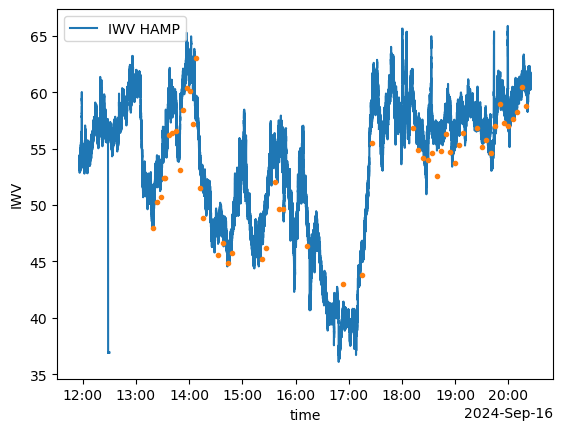

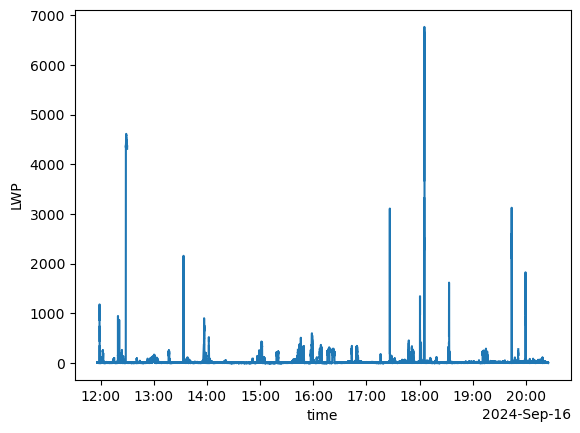

In [43]:
import pandas as pd
# selecting only one day:
# Define the target date
target_date = '2024-09-16'#'2024-09-19'#'2024-09-26'#'2024-08-11'#
target_datetime = pd.to_datetime(target_date)
ds_filtered = ds_sondes.where(ds_sondes['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)

"""

# Convert the target date to a pandas datetime object
target_datetime = pd.to_datetime(target_date)

# Filter the xarray dataset
# We need to select the time dimension based on the target date
filtered_ds_sondes = ds_sondes.sel(sonde_time=slice(target_datetime, target_datetime + pd.Timedelta(days=3)))
"""
ds_sondes_f = ds_sondes.where(ds_sondes['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)

ds_HAMP_f=ds_HAMP.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))

ds_iwv_kw_f=ds_iwv_kw.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))
iwv_v0=iwv_v0.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))
# Now filtered_ds_sondes contains only the entries for August 9, 2024
print(ds_sondes_f)
#ds_iwv_kw_f.IWV.plot(label='kw')
#iwv_v0.IWV.plot(label='IWV v0')
ds_HAMP_f.IWV.plot(label='IWV HAMP')

plt.plot(ds_sondes_f.sonde_time,ds_sondes_f.iwv,'.')
plt.legend()
plt.show()
#(ds_halo_altitude.alt.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))).plot()
#(ds_halo_altitude.alt.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))/100).plot()
ds_HAMP_f.LWP.plot(label='LWP HAMP')
plt.show()

In [27]:
a=ds_halo_altitude.alt.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))

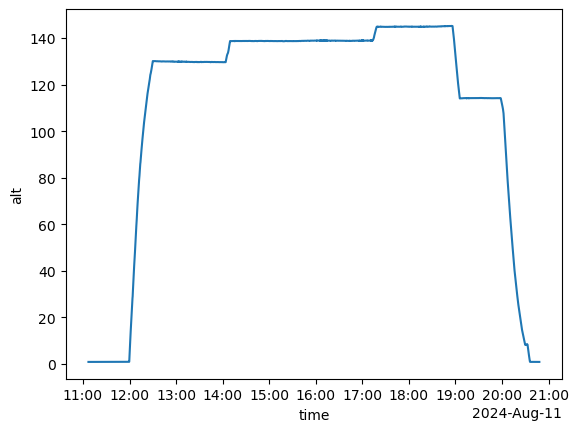

In [34]:
(ds_halo_altitude.alt.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))/100).plot()